In [13]:
%load_ext autoreload
%autoreload 2
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd

from sklearn.datasets import load_digits

In [ ]:
# load the digits dataset
digits = load_digits()

labels = digits['target']
# the data is in the same order as embedding (that was the training data)

# Create a DiscreteLatentSpace object with loading /gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav and /gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv

# Load the UMAP embedding to numpy
embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv', header=None)
embedding = embedding.values

# Load the UMAP model
with open('/gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav', 'rb') as f:
    umap_model = pickle.load(f)
    
# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=10)

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348
delete_heatmap: No heatmap with the name test_heatmap exists


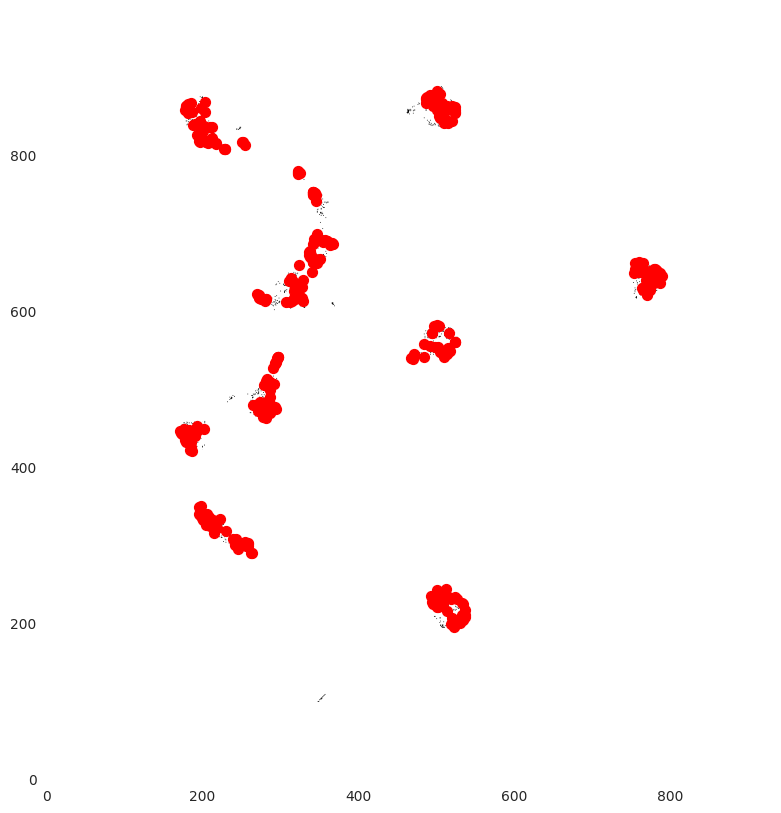

Smoothing the discrete space with a sigma of 21.233045007200477
Shape of the smoothed space: (359, 930, 987)
Sigma tuple: (0, 21.233045007200477, 21.233045007200477)
Shape of the smoothed n+1 dim discrete space: (359, 930, 987)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


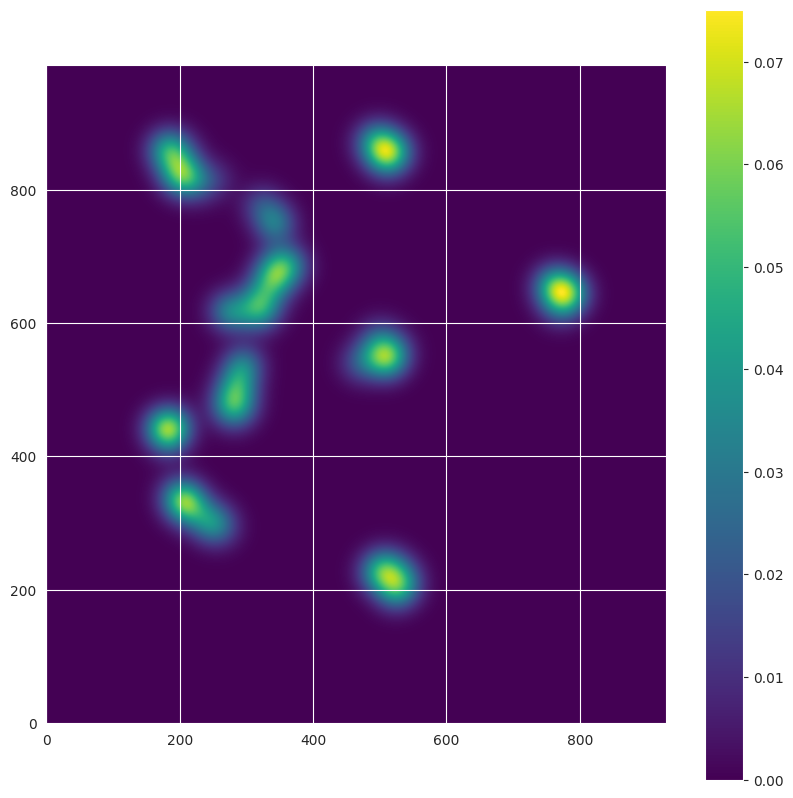

unique_vectors shape: (369031, 359)
vectors shape: (917910, 359)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [72]:
# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) with the last 10% of the embeddings
test_sub_embedding = embedding[-int(embedding.shape[0] * 0.2):]
# use the label as the score for the heatmap
sub_labels = labels[-int(embedding.shape[0] * 0.2):]
# normalise the labels between 0 and 1
sub_labels = (sub_labels - sub_labels.min()) / (sub_labels.max() - sub_labels.min())


# create the rescaled and discrete embeddings
dls.rescale_embedding(dls.raw_embeddings)
# dls.create_inverse_rescaled_embedding()
dls.create_discrete_space(dls.rescaled_embeddings, 10)
# delete the heatmap if it already exists
dls.delete_heatmap('test_heatmap')
dls.create_heatmap_spaces(test_sub_embedding, sub_labels, 'test_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='test_heatmap')

dls.plot_heatmap('test_heatmap', 50)

heatmap = dls.heatmaps['test_heatmap']

# Now I want to use compute_stats_on_smoothed_nplusone_dim_discrete_space and then display the statistics and the corrected p-values heatmap
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'
print(f'Heatmap shape: {heatmap.shape}')
statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics shape: {statistics.shape}')
statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics clusters shape: {statistics_clu.shape}')



 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (930, 987)
Number of non-Nan values: 373015


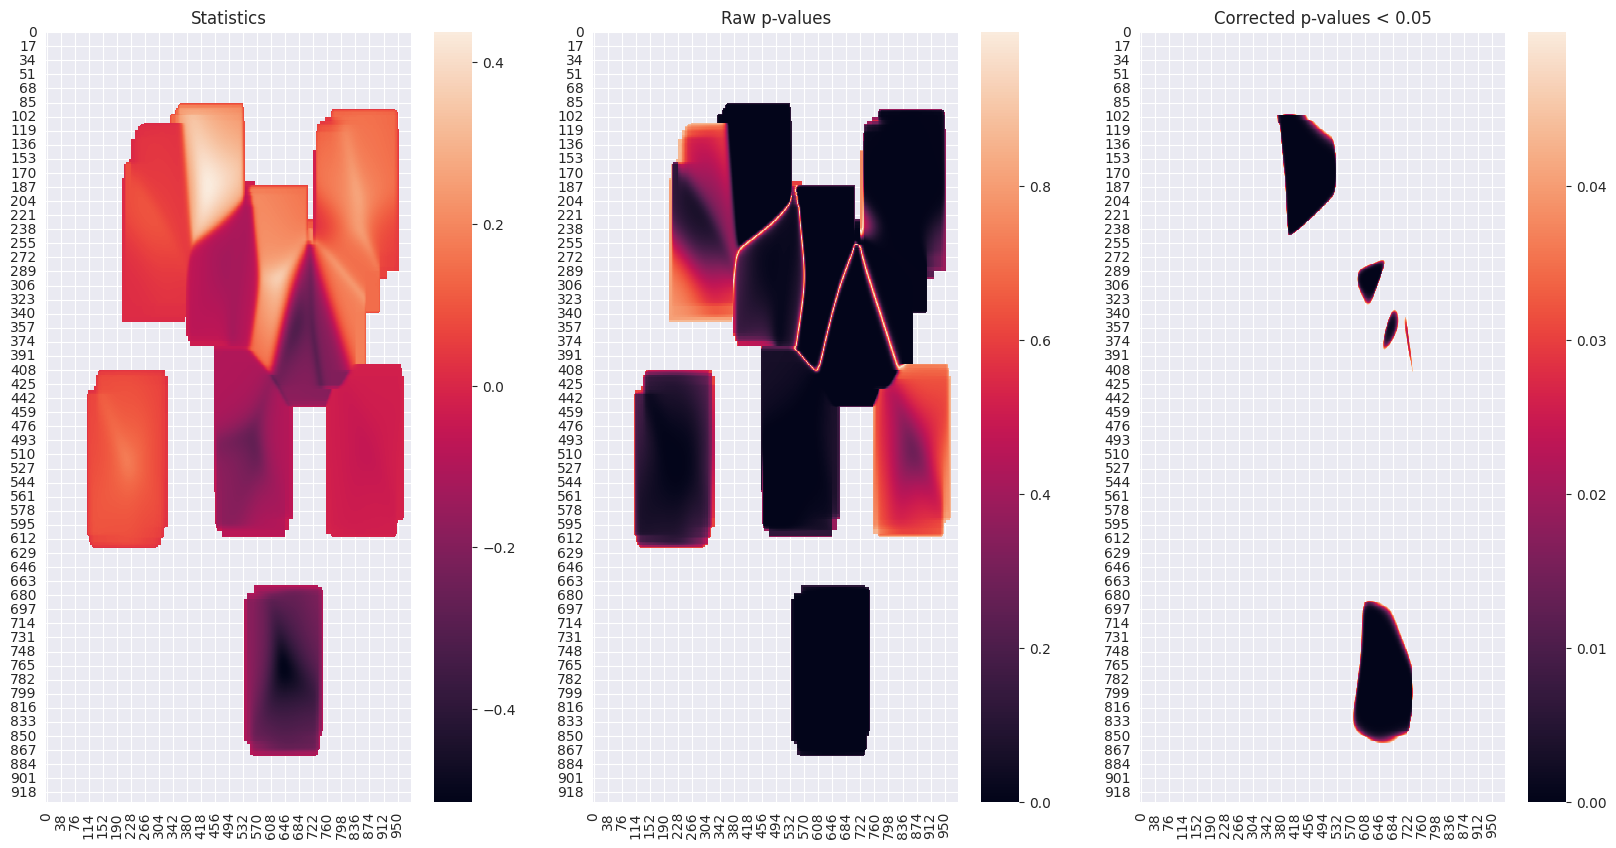

In [74]:
# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(20, 10))

sns.heatmap(statistics, ax=ax[0])
ax[0].set_title('Statistics')

# raw p-values
sns.heatmap(pvalues, ax=ax[1])
ax[1].set_title('Raw p-values')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Corrected p-values < 0.05')
else:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')

plt.show()



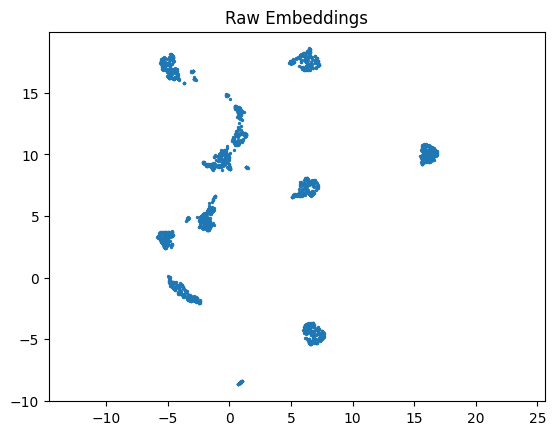

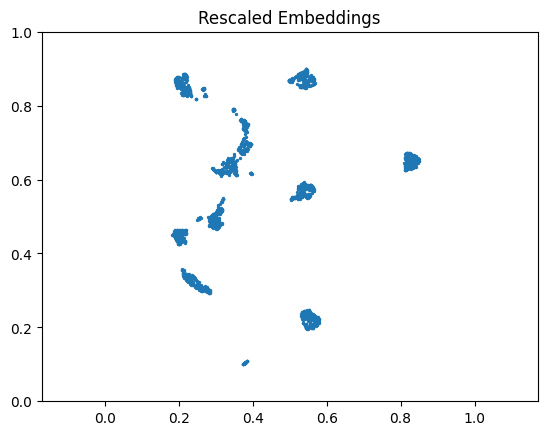

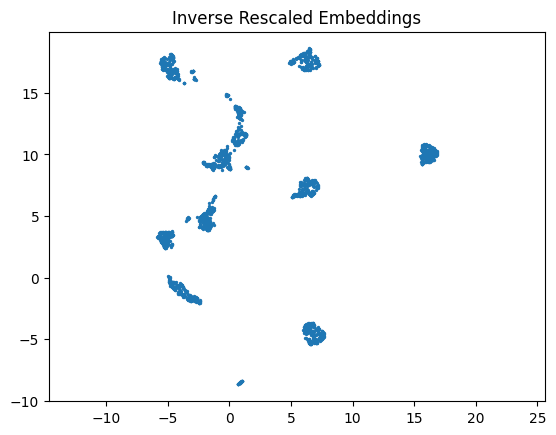

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348


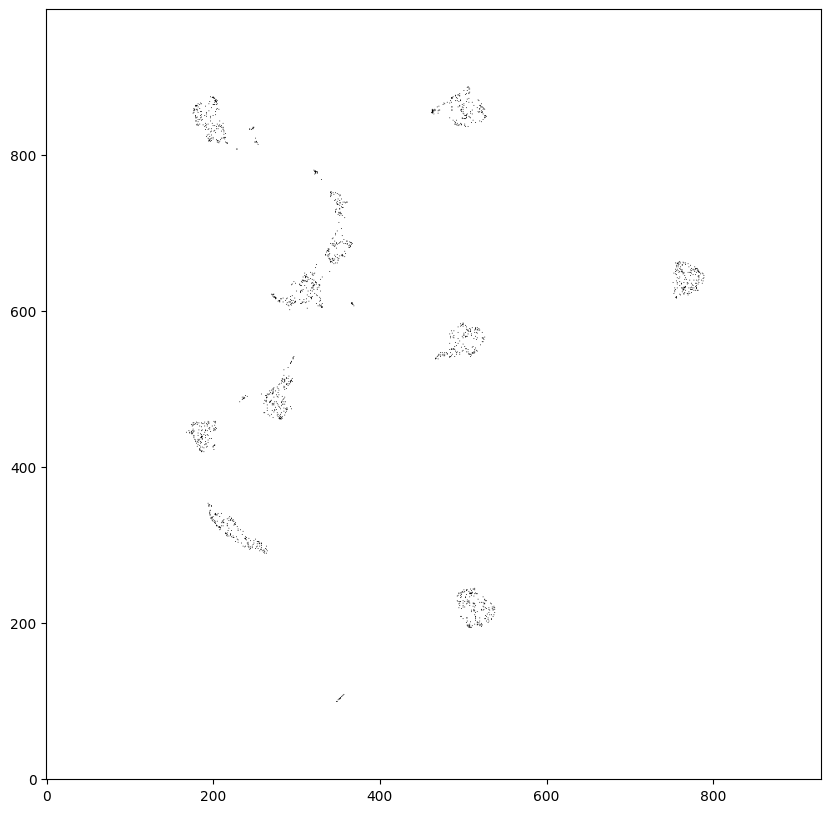

There is an overlap of 11.57% points in the discrete space
The number of cells in the discrete space is 722750
The shape of the discrete space is (826, 875)
Maximum in each dimension: 18.60238075256348


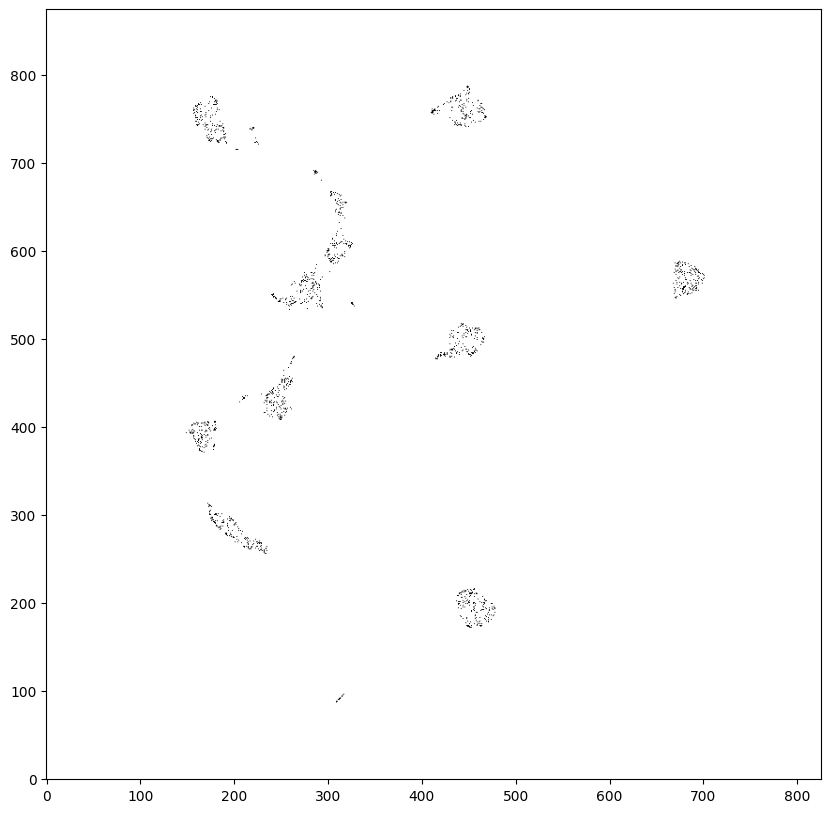

There is an overlap of 11.69% points in the discrete space
The number of cells in the discrete space is 722700
The shape of the discrete space is (825, 876)
Maximum in each dimension: 18.60238075256348


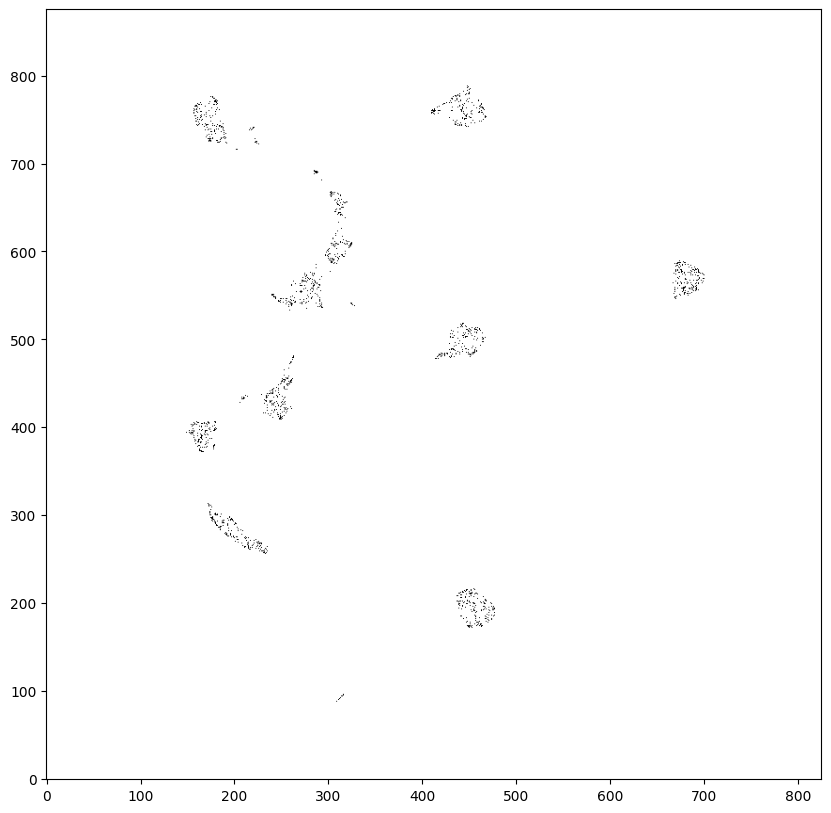

In [223]:
# plot the different versions of the embeddings in the latent space
dls.plot_raw_embedding()

dls.plot_rescaled_embedding()

dls.plot_inverse_rescaled_embedding()

dls.plot_discrete_embedding(10)

dls.plot_discrete_embedding(None, (826, 875))
dls.plot_discrete_embedding(None, (825, 876))


In [8]:
import os
import glob
from PIL import Image
import numpy as np
import pandas as pd

# image_paths_list_to_matrix
images_folder = "/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/Images"

# List all image files in the directory and its subdirectories
image_files = glob.glob(os.path.join(images_folder, '**', '*.*'), recursive=True)

# Filter the image files with a filename ending with "-N"
filtered_files = [f for f in image_files if os.path.splitext(os.path.basename(f))[0].endswith('-N')]

print(len(filtered_files))
print(f'Unique files names (without folder): {len(set([os.path.basename(f) for f in filtered_files]))}')

# save filtered_files as a csv
filtered_files_df = pd.DataFrame(filtered_files, columns=['image_path'])
filtered_files_df.to_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv', index=False)


# print the different resolutions (unique ones) of the images
# resolutions = set([np.array(Image.open(f)).shape for f in filtered_files])
# print(resolutions)


831
Unique files names (without folder): 831


In [4]:
from tqdm import tqdm
import importlib
import tools.inputs_utils

importlib.reload(tools.inputs_utils)

# images_list = [Image.open(img_path) for img_path in filtered_files]
# faces_input_matrix = image_paths_list_to_matrix(filtered_files, rescale=True)

def process_images(image_list, target_size=(128, 128)):
    images = []
    for img_path in tqdm(image_list):
        with Image.open(img_path) as img:
            img = img.resize(target_size)
            img_array = np.array(img, dtype=np.uint8)  # Use uint8 to save memory
            images.append(img_array.flatten())  # Flatten if necessary or adapt based on UMAP needs
    return np.array(images)

faces_input_matrix = process_images(filtered_files, (2407, 1662))

100%|██████████| 831/831 [01:53<00:00,  7.34it/s]


In [8]:
import scipy.sparse as sparse
# create an output folder for the trained umap and embeddings
output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
seed = 42

# create the output folder if it does not exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# faces_input_matrix = sparse.csr_matrix(faces_input_matrix, dtype=np.uint8)
    
# save the faces_input_matrix
np.save(os.path.join(output_folder, 'faces_input_matrix.npy'), faces_input_matrix)
# sparse.save_npz(os.path.join(output_folder, 'faces_input_matrix.npz'), faces_input_matrix)

MemoryError: Unable to allocate 148. GiB for an array with shape (9945723878, 2) and data type int64

In [ ]:
# train the umap model
from umap import UMAP

umap_model = UMAP(random_state=seed, verbose=True, n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean')
umap_embedding = umap_model.fit(faces_input_matrix)

In [12]:
import pickle
# save the umap model
with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'wb') as f:
    pickle.dump(umap_model, f)
    
# save the umap embedding
np.savetxt(os.path.join(output_folder, 'faces_embedding_42.csv'), umap_embedding.embedding_, delimiter=',')

In [5]:
import os 
import pandas as pd

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'

faces_embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)

print(faces_embedding.shape)

(831, 2)


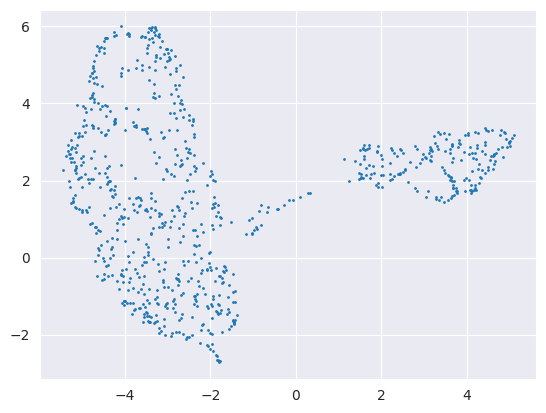

In [6]:
# plot the umap embedding
import matplotlib.pyplot as plt

plt.scatter(faces_embedding[0], faces_embedding[1], s=1)
plt.show()


In [9]:
# load /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx
info_dataframe = pd.read_excel('/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx', sheet_name=None, header=7)

# print sheet names
print(list(info_dataframe.keys()))

# create a dataframe maching the image names (filenames in filtered_files) with the "Model" column in all the "Norming Data" sheets. The filename should contain the "Model" column in the "Norming Data" sheets
import os
import pandas as pd
from pathlib import Path

# Get the common columns across all dataframes
common_columns = set(info_dataframe[list(info_dataframe.keys())[1]].columns)
for sheet_name, df in info_dataframe.items():
    if 'Norming Data' not in sheet_name:
        continue
    # print first 5 columns
    # print(df.columns[:5])
    common_columns.intersection_update(df.columns)
    
common_columns = list(common_columns)

# print(common_columns)

model_data = []
for sheet_name, df in info_dataframe.items():
    if "U.S. Norming Data" in sheet_name:
        # Only append the common columns
        model_data.append(df[common_columns])

# Create a new dataframe that contains the common data from all sheets
model_df = pd.concat(model_data, ignore_index=True)

# remove the rows with NaN values for Model
model_df = model_df.dropna(subset=['Model'])

# print(model_df.columns)

# print(f'Model in columns {"Model" in model_df.columns}')
# print(len(model_df['Model'].unique()))

path_model_match = {}

# Match the filename with the "Model" column
for img_path in filtered_files:
    img_name = Path(img_path).name
    found = False
    for model in model_df['Model']:
        # print(model)
        if model in img_name or model in img_name.replace('-', '', 2):
            if found:
                print(f"Multiple matches for {img_name}")
                break
            path_model_match[img_name] = model
            found = True
    if not found:
        print(f"No match for {img_name}")
        
# save the path_model_match dictionary in a json
import json

with open(os.path.join(output_folder, 'path_model_match.json'), 'w') as f:
    json.dump(path_model_match, f, indent=4)
    
# save the model_df dataframe filtered with only the matched models in a csv
model_df = model_df[model_df['Model'].isin(path_model_match.values())]
print(model_df.shape)
model_df.to_csv(os.path.join(output_folder, 'models_merged_df.csv'), index=False)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


['CFD 3.0 Codebook', 'CFD U.S. Norming Data', 'CFD-MR U.S. Norming Data', 'CFD-I U.S. Norming Data', 'CFD-I INDIA Norming Data']
No match for CFD-IM-719-221-N.jpg
No match for CFD-IM-638-250-2-N.jpg
No match for CFD-IF-644-306-2-N.jpg
No match for CFD-IF-714-008-2-N.jpg
No match for CFD-IF-677-452-2-N.jpg
(826, 118)


In [49]:
# Now I want to create a DiscreteLatentSpace object with the faces umap model and embedding
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd
import os

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
# Load the UMAP embedding to numpy
embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)
embedding = embedding.values

# Load the UMAP model
# with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'rb') as f:
#     umap_model = pickle.load(f)
    
umap_model = None
    
filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

print(filtered_files_df.columns)

# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=5)


Index(['image_path'], dtype='object')


There is an overlap of 4.93% points in the discrete space
The number of cells in the discrete space is 68000
The shape of the discrete space is (250, 272)
Maximum in each dimension: 6.000002384185791
Size of Attractive column: (826,)
Embedding shape: (831, 2)
Attractive embedding shape: (826, 2)


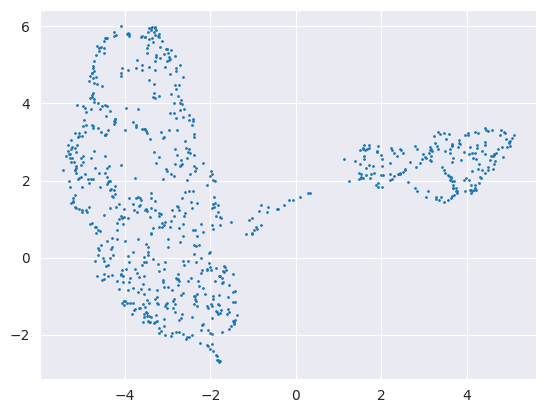

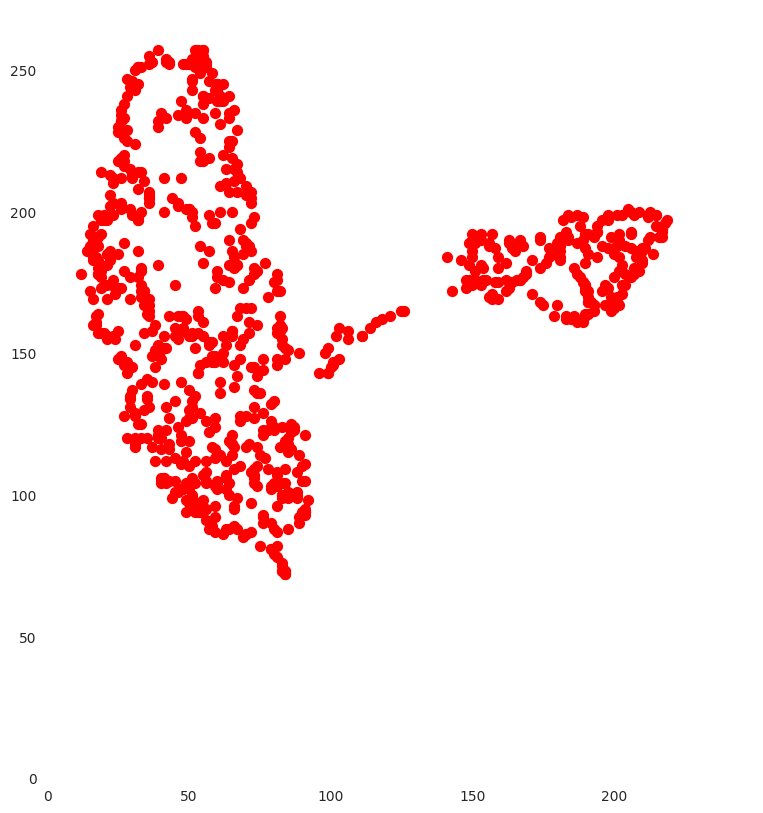

In [52]:
import json
from pathlib import Path

# Now I want to create the different spaces to finally create a heatmap and display the corrected p-values heatmap

dls.rescale_embedding(dls.raw_embeddings)
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) 


path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))
model_df = pd.read_csv(os.path.join(output_folder, 'models_merged_df.csv'))
# use the "Attractive" column in the model_df as the score for the heatmap
sub_labels = model_df['Attractive']
# Normalize the 'Attractive' column between 0 and 1 using 1 and 7 as boundaries
model_df['Attractive'] = (model_df['Attractive'] - 1) / (7 - 1)

print(f'Size of Attractive column: {model_df["Attractive"].shape}')

# the umap was trained with all the file but path_model_match contains only the matched files
# so I need to filter the embedding.
print(f'Embedding shape: {embedding.shape}')
attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]
print(f'Attractive embedding shape: {attractive_embedding.shape}')

# plot attractive_embedding
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], s=1)
plt.show()

# create the heatmap and all the spaces needed to compute the corrected p-values
dls.delete_heatmap('attractive_heatmap')
dls.create_heatmap_spaces(attractive_embedding, model_df['Attractive'], 'attractive_heatmap')

# create the heatmap raw, rescaled and discrete spaces
attractive_heatmap = dls.heatmaps['attractive_heatmap']

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='attractive_heatmap')

Smoothing the discrete space with a sigma of 2.1233045007200477
Shape of the smoothed space: (826, 250, 272)
Sigma tuple: (0, 2.1233045007200477, 2.1233045007200477)
Shape of the smoothed n+1 dim discrete space: (826, 250, 272)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


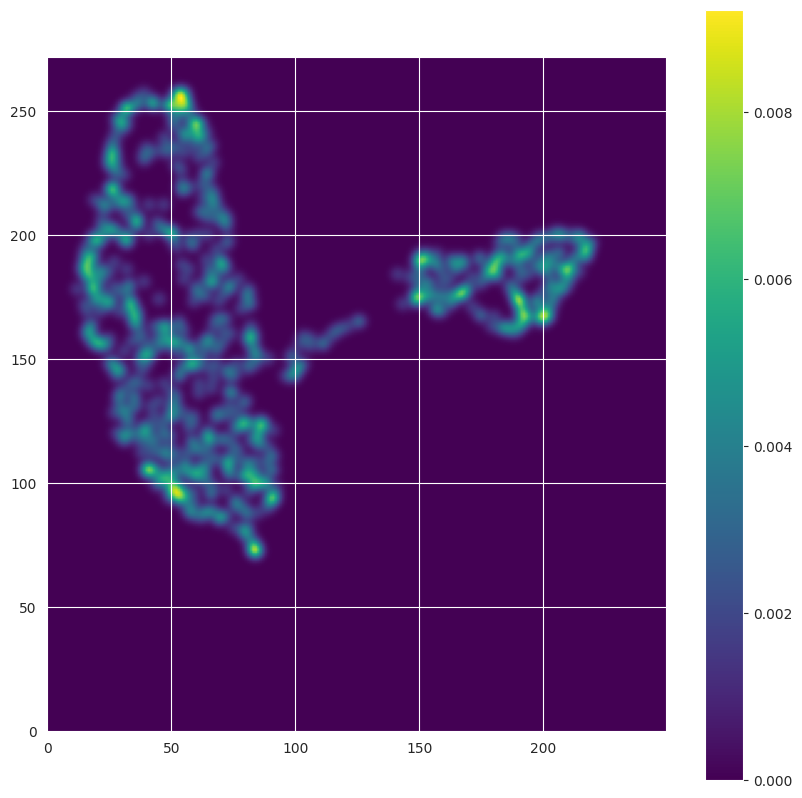

unique_vectors shape: (18276, 826)
vectors shape: (68000, 826)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (250, 272)
Number of non-Nan values: 18580


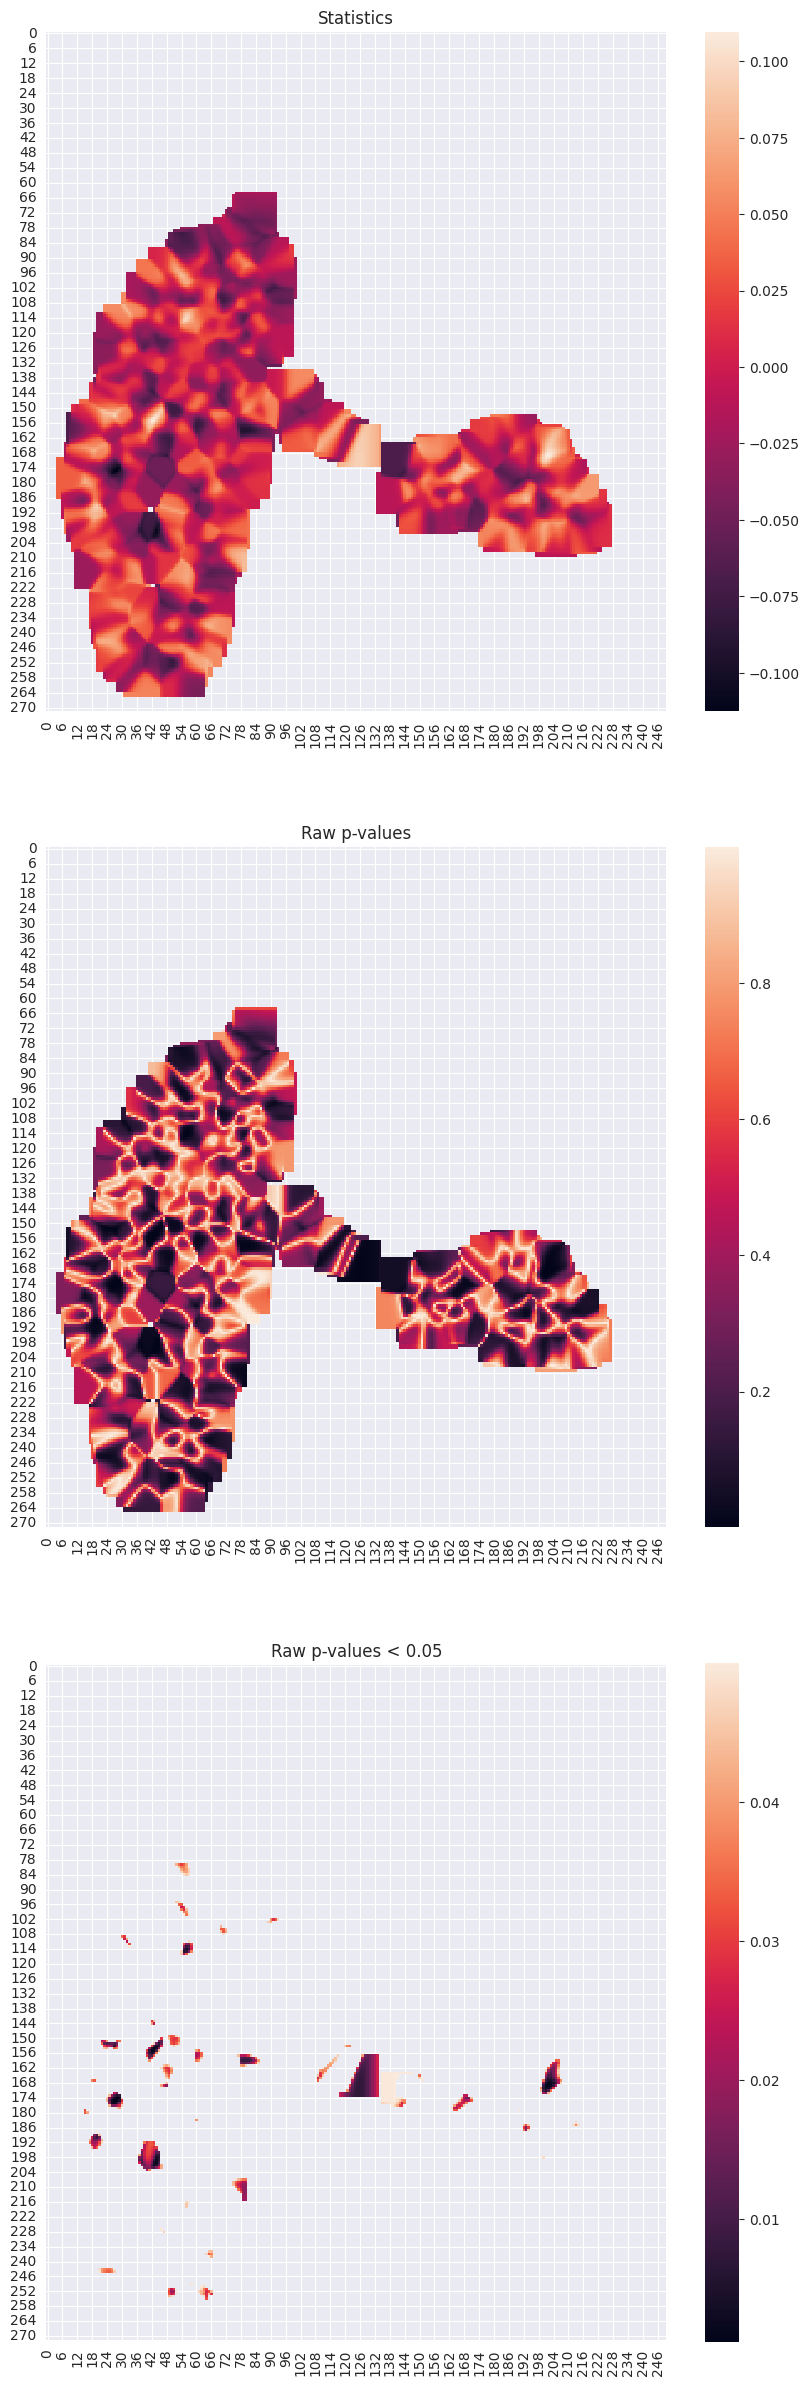

In [53]:
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('attractive_heatmap', 5)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

sns.heatmap(statistics.T, ax=ax[0])
ax[0].set_title('Statistics')
plt.axis('scaled')

# raw p-values
sns.heatmap(pvalues.T, ax=ax[1])
ax[1].set_title('Raw p-values')
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    if np.sum(~np.isnan(masked_pvalues)) > 0:
        sns.heatmap(masked_pvalues.T, ax=ax[2])
        ax[2].set_title('Corrected p-values')
if np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    if np.sum(~np.isnan(masked_pvalues_clu)) > 0:
        sns.heatmap(masked_pvalues_clu.T, ax=ax[2])
        ax[2].set_title('Corrected p-values clusters')
if np.sum(~np.isnan(masked_pvalues)) == 0 and np.sum(~np.isnan(masked_pvalues_clu)) == 0:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues.T, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')
    
plt.axis('scaled')
plt.show()


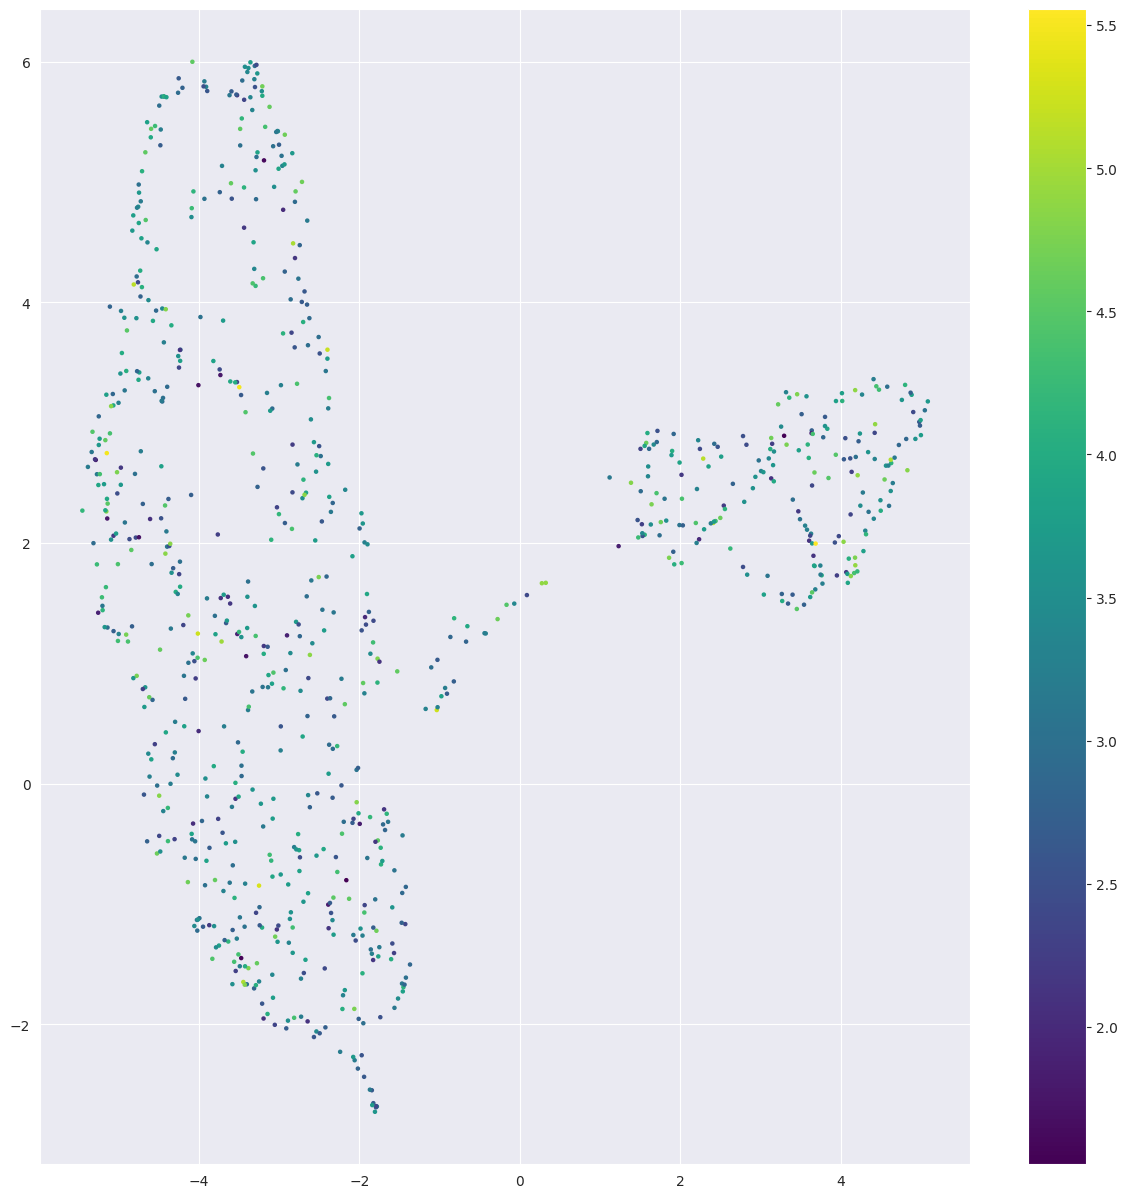

In [75]:
import matplotlib.pyplot as plt

embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/faces_embedding_42.csv', header=None).to_numpy()

filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))

attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]

model_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/models_merged_df.csv')

# plot the embedding with the attractive column as colour (and a colourbar)
variable = 'Attractive'
# increase figure size
plt.figure(figsize=(15, 15))
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], c=model_df[variable], cmap='viridis', s=5)
plt.colorbar()
# save the plot
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/attractive_embedding.png')
plt.show()


In [36]:
import joblib
from tools.inputs_utils import nifti_dataset_to_matrix
import pandas as pd
from pathlib import Path
import os

lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/lesion_masks_registered/'
# lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/disco/'

spreadsheet = pd.read_excel('/home/chrisfoulon/neuro_data/NEURAL_DATA/NEURAL_CUP_scores_training.xlsx', header=0, index_col=0)

# list nifti files in lesions_folder
lesions_list = [p for p in Path(lesions_folder).iterdir() if p.is_file()]

matched_lesions_list = []
for index in spreadsheet.index:
    found = False
    for i in lesions_list:
        formatted_str = index.replace('-', '')
        # the string must be 6 characters long not more (cut the last character if it is)
        if len(formatted_str) > 6:
            formatted_str = formatted_str[:-1]
        if formatted_str.replace('-', '') in i.name:
            matched_lesions_list.append(i)
            found = True
            break
    if not found:
        print(f'{index} not found')
        
# print columns of spreadsheet
print(spreadsheet.columns)

neural_input_matrix = nifti_dataset_to_matrix(matched_lesions_list)

output_folder = '/home/chrisfoulon/neuro_data/umap_tests_les/'

# load umap from /home/chrisfoulon/neuro_data/umap_tests_les/trained_umap.sav
trained_umap = joblib.load(os.path.join(output_folder, 'trained_umap.sav'))

# embed the neural_input_matrix with the trained umap
les_embeddings = trained_umap.transform(neural_input_matrix)


Index(['MOCA tot M12', 'Visuospatial M12', 'Denomination M12', 'Attention M12',
       'Langage M12', 'Abstraction M12', 'Rappel M12', 'Orientation M12',
       'Isaac M12', 'FM tot M12', 'FM moteur M12', 'HAD_A M12', 'HAD_D M12'],
      dtype='object')


187it [00:04, 46.08it/s]


There is an overlap of 3.74% points in the discrete space
The number of cells in the discrete space is 5035
The shape of the discrete space is (95, 53)
Maximum in each dimension: 12.373346328735352
delete_heatmap: No heatmap with the name neural_heatmap exists


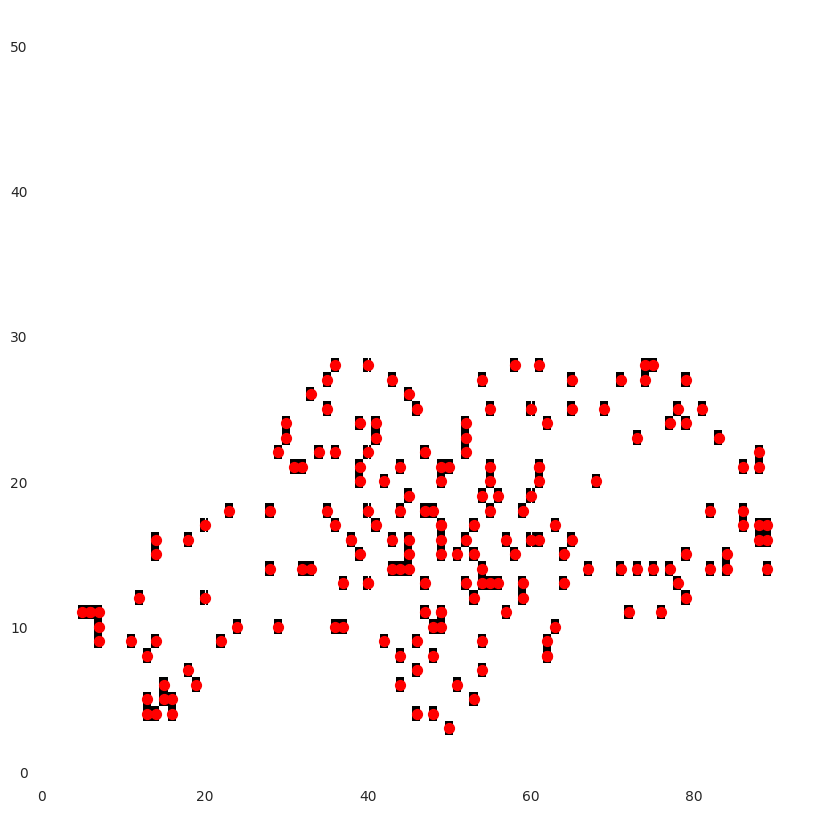

Smoothing the discrete space with a sigma of 1.6986436005760381
Shape of the smoothed space: (187, 95, 53)
Sigma tuple: (0, 1.6986436005760381, 1.6986436005760381)
Shape of the smoothed n+1 dim discrete space: (187, 95, 53)
Max value in the smoothed_nplusone_dim_discrete_space: 0.05517105800002826


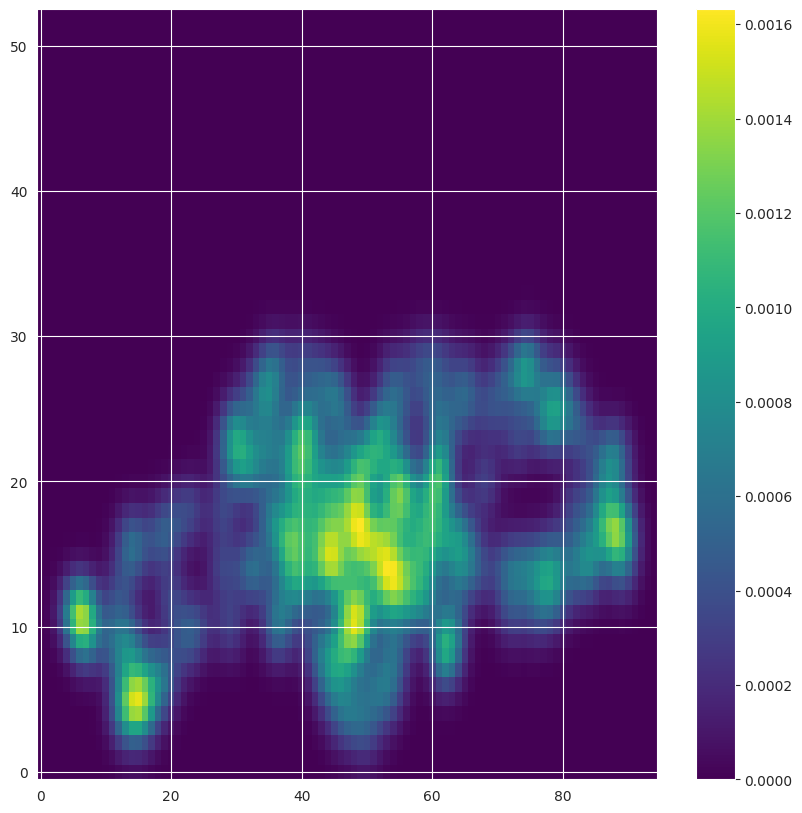

In [37]:
from tools.emuse_utils import DiscreteLatentSpace

test = "MOCA tot M12"
# test_scores needs to be a list
test_scores = spreadsheet[test].tolist()

# create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(trained_umap, les_embeddings, margin=5)

# rescale the embedding
dls.rescale_embedding(dls.raw_embeddings)

# create the discrete space
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create the heatmap
dls.delete_heatmap('neural_heatmap')
dls.create_heatmap_spaces(dls.raw_embeddings, test_scores, 'neural_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='neural_heatmap')

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 4)


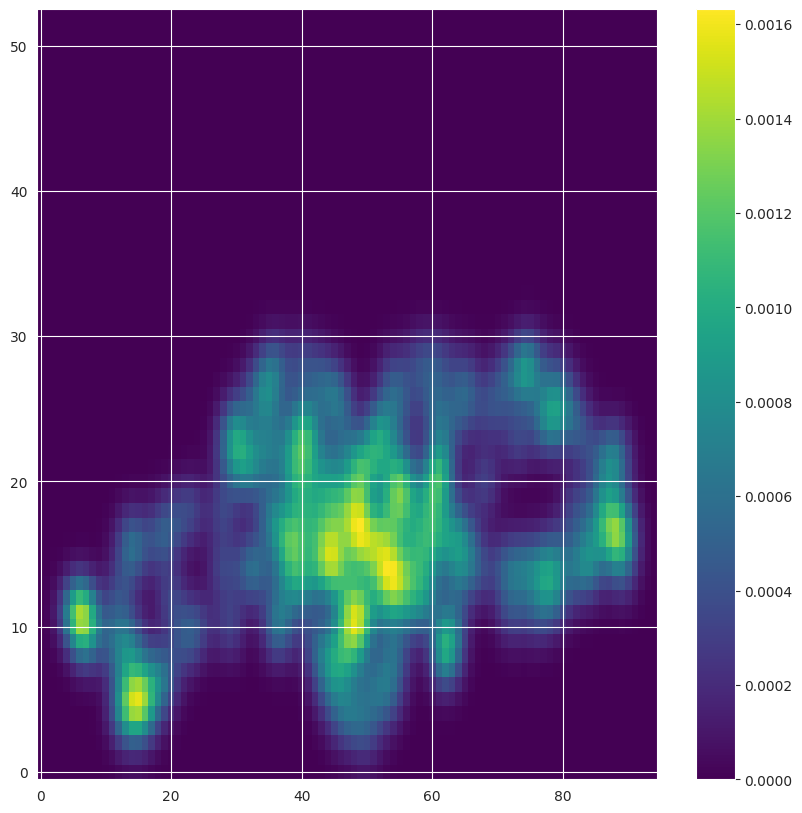

unique_vectors shape: (2894, 187)
vectors shape: (5035, 187)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (95, 53)
Number of non-Nan values: 2897
Number of non-Nan values: 2897


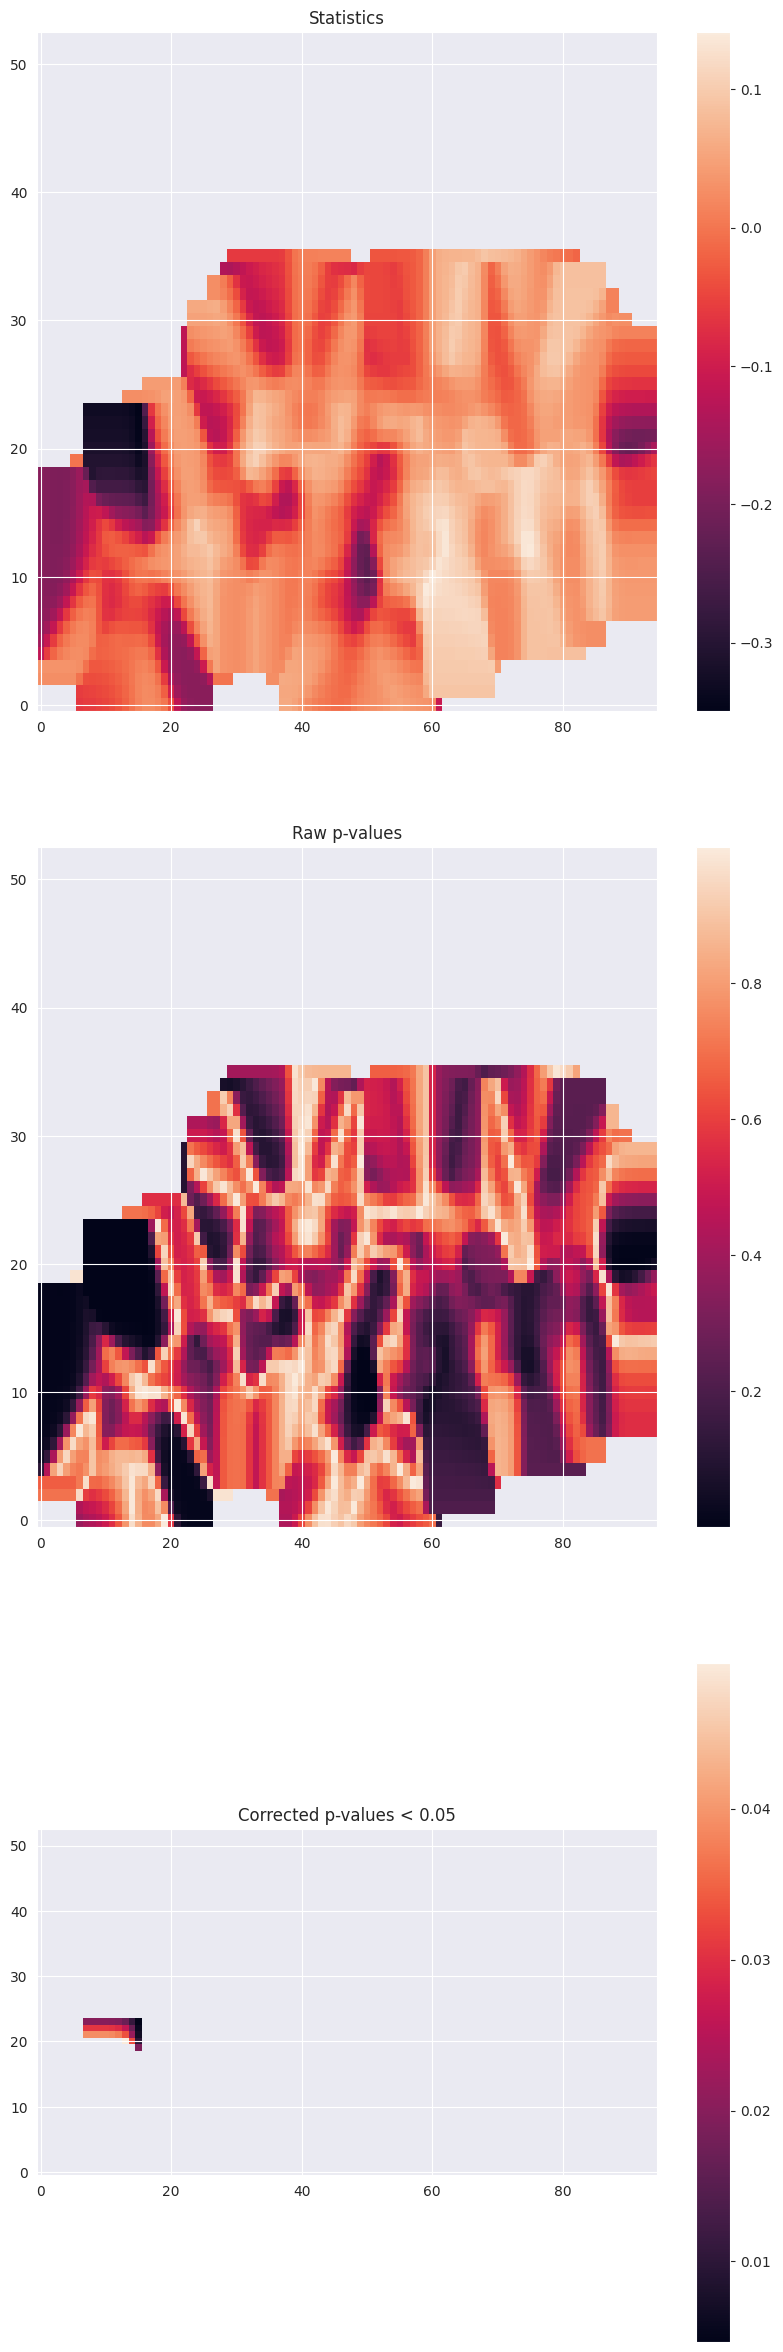

In [40]:
# compute the statistics and corrected p-values
import numpy as np
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 10)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

# Statistics
im = ax[0].imshow(statistics.T, origin='lower', aspect='auto')
ax[0].set_title('Statistics')
fig.colorbar(im, ax=ax[0])
plt.axis('scaled')

# Raw p-values
im = ax[1].imshow(pvalues.T, origin='lower', aspect='auto')
ax[1].set_title('Raw p-values')
fig.colorbar(im, ax=ax[1])
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')
print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')
    masked_corrected_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values < 0.05')
elif np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    print(f'Number of non-Nan values (clusters): {np.sum(~np.isnan(corrected_pvalues_clu))}')
    masked_corrected_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues_clu.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values clusters < 0.05')
else:
    print(f'Number of non-Nan values (raw p-values): {np.sum(pvalues < 0.05)}')
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    im = ax[2].imshow(masked_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Raw p-values < 0.05')

fig.colorbar(im, ax=ax[2])
plt.axis('scaled')
plt.show()

Predicted value: 4.474059295602397, Standard deviation: 1.6039558705943955


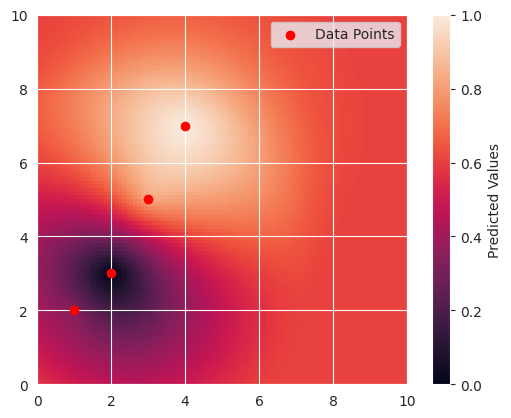

In [2]:
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt

# Sample data: coordinates (x, y) and values (z)
X = np.array([1, 2, 3, 4], dtype=np.float64)
Y = np.array([2, 3, 5, 7], dtype=np.float64)
Z = np.array([3.0, 2.0, 4.5, 5.0], dtype=np.float64)

# Creating an Ordinary Kriging model
OK = OrdinaryKriging(X, Y, Z, variogram_model='spherical')

# Coordinates where we want to predict the values
X_new = np.array([5], dtype=np.float64)
Y_new = np.array([8], dtype=np.float64)

# Performing the prediction
Z_pred, ss = OK.execute('points', X_new, Y_new)

print(f"Predicted value: {Z_pred[0]}, Standard deviation: {ss[0]}")

# Visualization (optional)
gridx = np.linspace(0.0, 10.0, 100)
gridy = np.linspace(0.0, 10.0, 100)
z, ss = OK.execute('grid', gridx, gridy)

plt.imshow(z, extent=(0, 10, 0, 10), origin='lower')
plt.scatter(X, Y, c='r', label='Data Points')
plt.colorbar(label='Predicted Values')
plt.legend()
plt.show()
 

In [13]:
from tools.inputs_utils import load_and_preprocess_mnist_dataset
from sklearn.datasets import fetch_openml

# Load data from https://www.openml.org/d/554
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()

print(f'MNIST features shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Min max values: pixel1      0.0
pixel2      0.0
pixel3      0.0
pixel4      0.0
pixel5      0.0
           ... 
pixel780    0.0
pixel781    0.0
pixel782    0.0
pixel783    0.0
pixel784    0.0
Length: 784, dtype: float64, pixel1       0.0
pixel2       0.0
pixel3       0.0
pixel4       0.0
pixel5       0.0
            ... 
pixel780    62.0
pixel781     0.0
pixel782     0.0
pixel783     0.0
pixel784     0.0
Length: 784, dtype: float64
MNIST features shape: (70000, 784)
MNIST labels shape: (70000,)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Leaving out 90% of the dataset for testing
Completed evaluation with 90% left out
Leaving out 91% of the dataset for testing
Completed evaluation with 91% left out
Leaving out 92% of the dataset for testing
Completed evaluation with 92% left out
Leaving out 93% of the dataset for testing
Completed evaluation with 93% left out
Leaving out 94% of the dataset for testing
Completed evaluation with 94% left out
Leave out 90%: Fold Accuracy = 0.9380, Left Out Accuracy = 0.9411
Leave out 91%: Fold Accuracy = 0.9340, Left Out Accuracy = 0.9370
Leave out 92%: Fold Accuracy = 0.9305, Left Out Accuracy = 0.9368
Leave out 93%: Fold Accuracy = 0.9278, Left Out Accuracy = 0.9355
Leave out 94%: Fold Accuracy = 0.9279, Left Out Accuracy = 0.9317


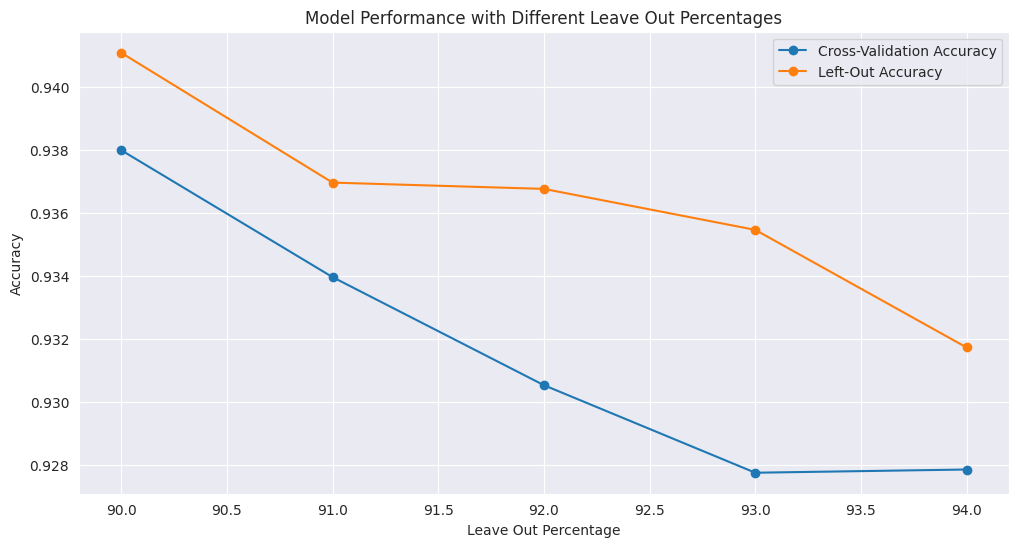

In [8]:
"""
Trying different left out proportions to see the performance of the random forest
"""
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from tools.inputs_utils import load_and_preprocess_mnist_dataset

# Load and preprocess the MNIST dataset
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()
mnist_features_normalized = mnist_features_normalized.to_numpy()
mnist_labels = mnist_labels.to_numpy()

# Shuffle the dataset
indices = np.arange(len(mnist_features_normalized))
np.random.shuffle(indices)
mnist_features_normalized = mnist_features_normalized[indices]
mnist_labels = mnist_labels[indices]

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# List to store results
results = []

# Loop to leave out different portions of the dataset
for leave_out_percentage in range(90, 95, 1):
    leave_out_size = int(len(mnist_features_normalized) * (leave_out_percentage / 100))
    X_left_out = mnist_features_normalized[:leave_out_size]
    y_left_out = mnist_labels[:leave_out_size]
    X_remaining = mnist_features_normalized[leave_out_size:]
    y_remaining = mnist_labels[leave_out_size:]
    
    print(f"Leaving out {leave_out_percentage}% of the dataset for testing")

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    fold_accuracies = []
    left_out_accuracies = []

    for train_index, test_index in kf.split(X_remaining):
        X_train, X_test = X_remaining[train_index], X_remaining[test_index]
        y_train, y_test = y_remaining[train_index], y_remaining[test_index]
        
        # Perform grid search with cross-validation for hyperparameter tuning
        rf = RandomForestClassifier(random_state=42)
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
        
        # Fit the model
        grid_search.fit(X_train, y_train)
        best_rf = grid_search.best_estimator_
        
        # Predict the labels for the test set
        y_pred = best_rf.predict(X_test)
        
        # Calculate the accuracy for this fold
        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_accuracies.append(fold_accuracy)
    
    # Test on the left-out dataset
    y_left_out_pred = best_rf.predict(X_left_out)
    left_out_accuracy = accuracy_score(y_left_out, y_left_out_pred)
    left_out_accuracies.append(left_out_accuracy)
    
    results.append({
        'leave_out_percentage': leave_out_percentage,
        'fold_accuracies': fold_accuracies,
        'left_out_accuracy': left_out_accuracy
    })

    print(f"Completed evaluation with {leave_out_percentage}% left out")

# Calculate the average accuracy across all folds for each leave out percentage
for result in results:
    avg_fold_accuracy = np.mean(result['fold_accuracies'])
    print(f"Leave out {result['leave_out_percentage']}%: Fold Accuracy = {avg_fold_accuracy:.4f}, Left Out Accuracy = {result['left_out_accuracy']:.4f}")

# Plot the results
leave_out_percentages = [result['leave_out_percentage'] for result in results]
fold_accuracies = [np.mean(result['fold_accuracies']) for result in results]
left_out_accuracies = [result['left_out_accuracy'] for result in results]

plt.figure(figsize=(12, 6))
plt.plot(leave_out_percentages, fold_accuracies, label='Cross-Validation Accuracy', marker='o')
plt.plot(leave_out_percentages, left_out_accuracies, label='Left-Out Accuracy', marker='o')
plt.xlabel('Leave Out Percentage')
plt.ylabel('Accuracy')
plt.title('Model Performance with Different Leave Out Percentages')
plt.legend()
plt.grid(True)
plt.show()


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Min max values: pixel1      0.0
pixel2      0.0
pixel3      0.0
pixel4      0.0
pixel5      0.0
           ... 
pixel780    0.0
pixel781    0.0
pixel782    0.0
pixel783    0.0
pixel784    0.0
Length: 784, dtype: float64, pixel1       0.0
pixel2       0.0
pixel3       0.0
pixel4       0.0
pixel5       0.0
            ... 
pixel780    62.0
pixel781     0.0
pixel782     0.0
pixel783     0.0
pixel784     0.0
Length: 784, dtype: float64
MNIST features shape: (70000, 784)
MNIST labels shape: (70000,)
Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Fold 1/5 Accuracy: 0.9677857142857142
Model checkpoint saved for fold 1 at ./mnist_model_checkpoints/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Fold 2/5 Accuracy: 0.97
Model checkpoint saved for fold 2 at ./mnist_model_checkpoints/rf_model_fold_2.pkl


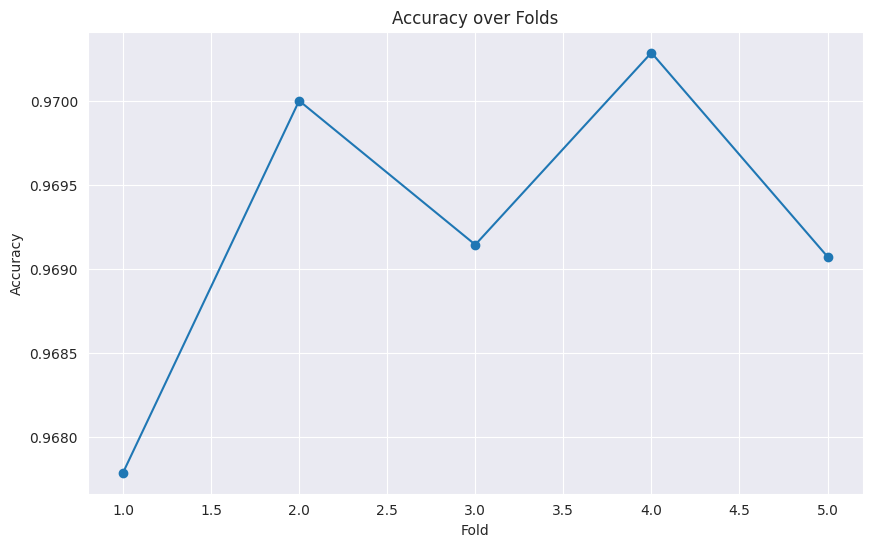


Classification Report for the last fold:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1375
           1       0.98      0.98      0.98      1613
           2       0.97      0.96      0.97      1414
           3       0.97      0.96      0.96      1414
           4       0.96      0.98      0.97      1364
           5       0.98      0.96      0.97      1265
           6       0.98      0.99      0.98      1360
           7       0.97      0.97      0.97      1429
           8       0.96      0.96      0.96      1375
           9       0.95      0.94      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



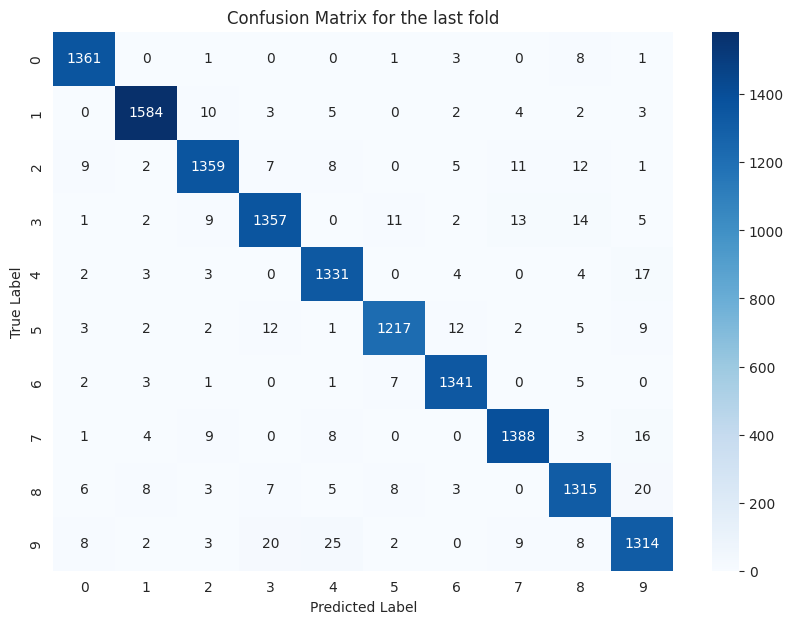

In [15]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from tools.inputs_utils import load_and_preprocess_mnist_dataset

# Load and preprocess the MNIST dataset
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()
mnist_features_normalized = mnist_features_normalized.to_numpy()
mnist_labels = mnist_labels.to_numpy()

print(f'MNIST features shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')

output_folder = './mnist_model_checkpoints'

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store accuracy for each fold
accuracy_scores = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_features_normalized)
current_fold = 1

# Define the parameter grid for hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Random Forest with Flattened Image Data
for train_index, test_index in kf.split(mnist_features_normalized):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_features_normalized[train_index], mnist_features_normalized[test_index]
    y_train, y_test = mnist_labels[train_index], mnist_labels[test_index]
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Calculate the accuracy for this fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    print(f"Fold {current_fold}/{total_folds} Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average accuracy across all folds
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Accuracy: {avg_accuracy}')

# Plot the evolution of the accuracy over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(accuracy_scores) + 1), accuracy_scores, marker='o')
plt.title('Accuracy over Folds')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the last fold
print("\nClassification Report for the last fold:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the last fold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


MNIST embedding shape: (70000, 2)
MNIST labels shape: (70000, 1)
MNIST features left out shape: (3500, 2)
MNIST labels left out shape: (3500, 1)
MNIST features remaining shape: (66500, 2)
MNIST labels remaining shape: (66500, 1)
There is an overlap of 9.93% points in the discrete space
The number of cells in the discrete space is 3094248
The shape of the discrete space is (1832, 1689)
Maximum in each dimension: 17.169851303100586
delete_heatmap: No heatmap with the name mnist_heatmap exists
Shape embeddings_scores_df:  (3500, 2)


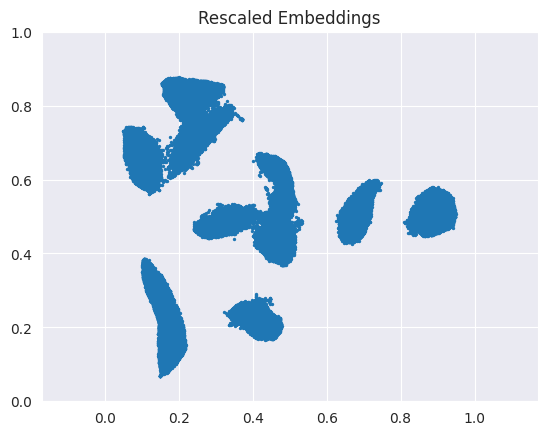

Creating heatmap


In [45]:
# load /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/embeddings.npy and plot it
import numpy as np
import pandas as pd

mnist_features_normalized = np.load('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/embeddings.npy')
mnist_labels = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/mnist_labels.csv', header=0).to_numpy()

# shuffle the indices
indices = np.arange(len(mnist_features_normalized))
np.random.shuffle(indices)
mnist_features_normalized = mnist_features_normalized[indices]
mnist_labels = mnist_labels[indices]

# take 5% out of the dataset (features ans labels)
leave_out_size = int(len(mnist_features_normalized) * 0.05)
mnist_features_normalized_left_out = mnist_features_normalized[:leave_out_size]
mnist_labels_left_out = mnist_labels[:leave_out_size]
mnist_features_normalized_remaining = mnist_features_normalized[leave_out_size:]
mnist_labels_remaining = mnist_labels[leave_out_size:]

print(f'MNIST embedding shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')
print(f'MNIST features left out shape: {mnist_features_normalized_left_out.shape}')
print(f'MNIST labels left out shape: {mnist_labels_left_out.shape}')
print(f'MNIST features remaining shape: {mnist_features_normalized_remaining.shape}')
print(f'MNIST labels remaining shape: {mnist_labels_remaining.shape}')

# now create a DiscreteLatentSpace object with the remaining features and labels
from tools.emuse_utils import DiscreteLatentSpace

dls = DiscreteLatentSpace(None, mnist_features_normalized_remaining, margin=5)
# create the discrete space (remember to rescale the embedding)
dls.rescale_embedding(dls.raw_embeddings)
dls.create_discrete_space(dls.rescaled_embeddings, 10)

# create a heatmap with the left out features and labels
dls.delete_heatmap('mnist_heatmap')
# for the heatmap the parameter is a dataframe embeddings_scores_df with the embeddings (one tuple a cell) and associated scores
col_names = ['coord', 'labels']
embeddings_scores_df = pd.DataFrame(data={'coord': [tuple(coord) for coord in mnist_features_normalized_left_out], 'labels': mnist_labels_left_out.flatten()}, columns=col_names)
print('Shape embeddings_scores_df: ', embeddings_scores_df.shape)

# plot the rescaled embeddings
dls.plot_rescaled_embedding()

# plot the heatmap

print('Creating heatmap')
# 
# dls.create_heatmap_spaces(embeddings_scores_df, 'mnist_heatmap', smoothing_fwhm=10)
# dls.plot_discrete_embedding(heatmap_name='mnist_heatmap')
# plot the heatmap
# dls.plot_heatmap('mnist_heatmap')



Accuracy: 0.9115939849624061

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      6561
         1.0       0.96      0.86      0.90      7478
         2.0       0.85      0.92      0.89      6651
         3.0       0.92      0.89      0.91      6745
         4.0       0.90      0.91      0.91      6475
         5.0       0.90      0.92      0.91      6015
         6.0       0.89      0.98      0.93      6507
         7.0       0.89      0.94      0.91      6935
         8.0       0.88      0.87      0.87      6483
         9.0       0.96      0.85      0.90      6650

    accuracy                           0.91     66500
   macro avg       0.91      0.91      0.91     66500
weighted avg       0.91      0.91      0.91     66500



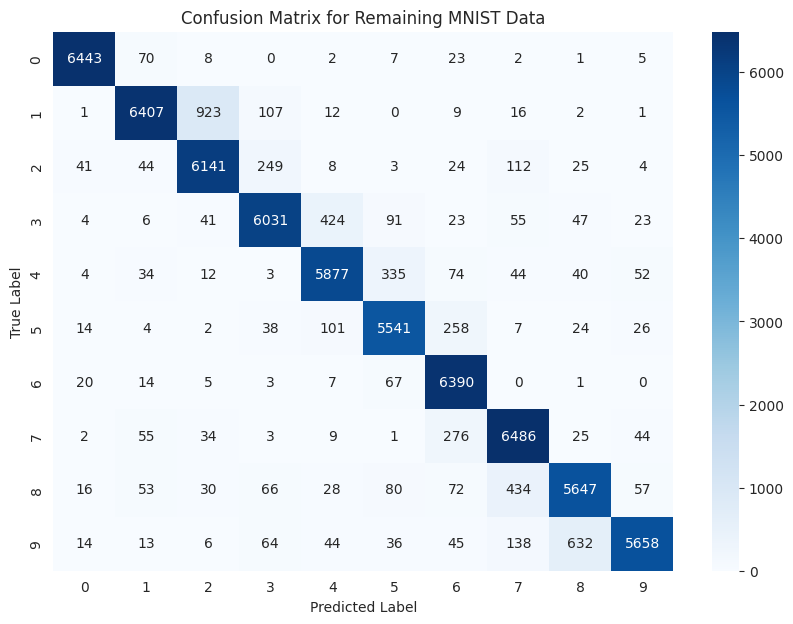

Min max ss: 1.2879680532151947 11.734969969976339


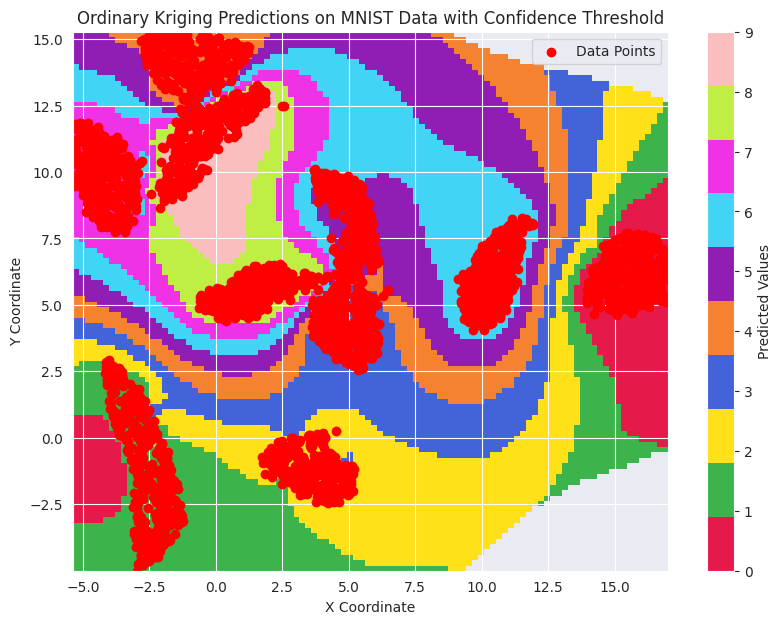

In [20]:
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming mnist_features_normalized_left_out and mnist_labels_left_out are already loaded
mnist_features = mnist_features_normalized_left_out
mnist_labels = mnist_labels_left_out.astype(float)

# Assuming mnist_features_normalized_remaining and mnist_labels_remaining are already loaded
mnist_features_remaining = mnist_features_normalized_remaining
mnist_labels_remaining = mnist_labels_remaining.astype(float)

# Extracting the coordinates (X, Y) and values (Z) for Kriging
X = mnist_features[:, 0]
Y = mnist_features[:, 1]
Z = mnist_labels

# Creating an Ordinary Kriging model
OK = OrdinaryKriging(X, Y, Z, variogram_model='spherical')

# Coordinates where we want to predict the values
X_new = mnist_features_remaining[:, 0]
Y_new = mnist_features_remaining[:, 1]

# Performing the prediction
Z_pred, ss = OK.execute('points', X_new, Y_new)

# Round predictions to nearest integer to evaluate classification accuracy
Z_pred_rounded = np.round(Z_pred)

# Calculate accuracy
accuracy = accuracy_score(mnist_labels_remaining, Z_pred_rounded)
print(f'Accuracy: {accuracy}')

# Print classification report
print("\nClassification Report:")
print(classification_report(mnist_labels_remaining, Z_pred_rounded))

# Confusion matrix
conf_matrix = confusion_matrix(mnist_labels_remaining, Z_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Remaining MNIST Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Define a list of 10 distinct colors
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabebe"
]

# Create a ListedColormap
cmap = ListedColormap(colors)

# Visualization with custom colormap
gridx = np.linspace(X.min(), X.max(), 100)
gridy = np.linspace(Y.min(), Y.max(), 100)
z, ss = OK.execute('grid', gridx, gridy)

print(f'Min max ss: {ss.min()} {ss.max()}')

# Define confidence threshold (variance threshold)
confidence_threshold = 8  # Adjust this value based on your needs

# Set predictions with variance above the threshold to NaN
z[ss > confidence_threshold] = np.nan

plt.figure(figsize=(10, 7))
plt.imshow(z, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=cmap, vmin=0, vmax=9)
cb = plt.colorbar(label='Predicted Values', ticks=np.arange(10))
cb.set_ticklabels(np.arange(10))
plt.scatter(X, Y, c='r', label='Data Points')
plt.legend()
plt.title('Ordinary Kriging Predictions on MNIST Data with Confidence Threshold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
# Save as svg
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/kriging_mnist_with_confidence.svg')
plt.show()


Accuracy: 0.8907368421052632

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      6563
         1.0       0.94      0.86      0.90      7482
         2.0       0.85      0.93      0.89      6641
         3.0       0.90      0.88      0.89      6750
         4.0       0.91      0.86      0.88      6495
         5.0       0.84      0.88      0.86      5989
         6.0       0.78      0.97      0.86      6514
         7.0       0.89      0.84      0.86      6960
         8.0       0.90      0.87      0.88      6488
         9.0       0.96      0.87      0.91      6618

    accuracy                           0.89     66500
   macro avg       0.89      0.89      0.89     66500
weighted avg       0.90      0.89      0.89     66500



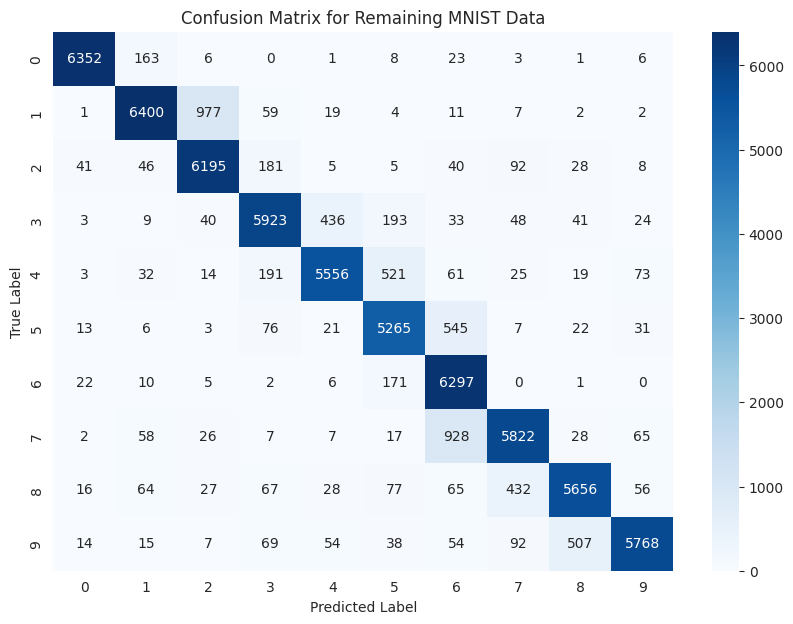

Min max ss: 0.034253480080450614 9.877431302356117


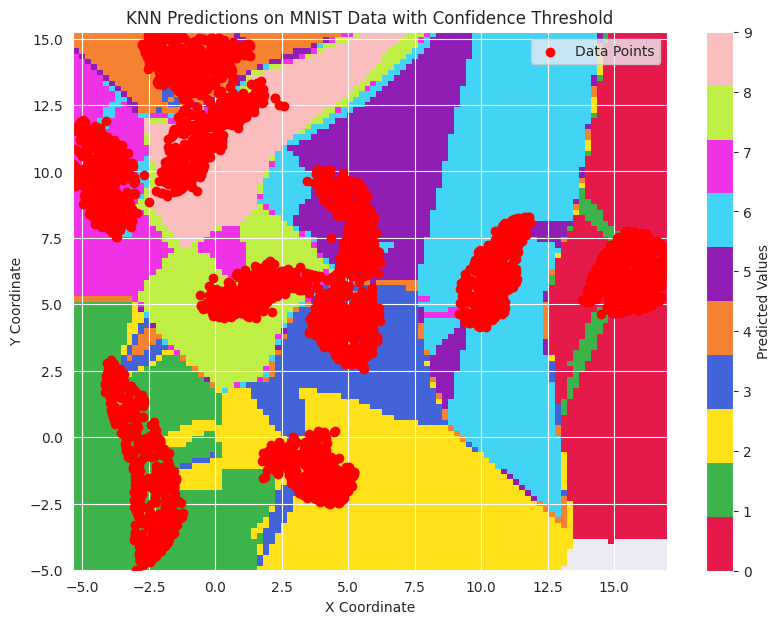

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsRegressor

# Assuming mnist_features_normalized_left_out and mnist_labels_left_out are already loaded
mnist_features = mnist_features_normalized_left_out
mnist_labels = mnist_labels_left_out.astype(float)

# Assuming mnist_features_normalized_remaining and mnist_labels_remaining are already loaded
mnist_features_remaining = mnist_features_normalized_remaining
mnist_labels_remaining = mnist_labels_remaining.astype(float)

# Extracting the coordinates (X, Y) and values (Z) for KNN
X = mnist_features[:, 0]
Y = mnist_features[:, 1]
Z = mnist_labels

# Creating a KNN model
knn = KNeighborsRegressor(n_neighbors=5)

# Training the KNN model
knn.fit(mnist_features, mnist_labels)

# Coordinates where we want to predict the values
X_new = mnist_features_remaining[:, 0]
Y_new = mnist_features_remaining[:, 1]

# Performing the prediction
Z_pred = knn.predict(mnist_features_remaining)

# Round predictions to nearest integer to evaluate classification accuracy
Z_pred_rounded = np.round(Z_pred)

# Calculate accuracy
accuracy = accuracy_score(mnist_labels_remaining, Z_pred_rounded)
print(f'Accuracy: {accuracy}')

# Print classification report
print("\nClassification Report:")
print(classification_report(mnist_labels_remaining, Z_pred_rounded))

# Confusion matrix
conf_matrix = confusion_matrix(mnist_labels_remaining, Z_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Remaining MNIST Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Define a list of 10 distinct colors
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabebe"
]

# Create a ListedColormap
cmap = ListedColormap(colors)

# Visualization with custom colormap
gridx = np.linspace(X.min(), X.max(), 100)
gridy = np.linspace(Y.min(), Y.max(), 100)
grid_x, grid_y = np.meshgrid(gridx, gridy)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]

# Predict the grid
z = knn.predict(grid_points)
z = z.reshape(grid_x.shape)

# Estimate the confidence (using the inverse of the distance to the nearest neighbors)
distances, _ = knn.kneighbors(grid_points)
ss = distances.mean(axis=1)
ss = ss.reshape(grid_x.shape)

print(f'Min max ss: {ss.min()} {ss.max()}')

# Define confidence threshold (distance threshold)
confidence_threshold = np.percentile(ss, 99)  # Adjust this value based on your needs

# Set predictions with variance above the threshold to NaN
z[ss > confidence_threshold] = np.nan

plt.figure(figsize=(10, 7))
plt.imshow(z, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=cmap, vmin=0, vmax=9)
cb = plt.colorbar(label='Predicted Values', ticks=np.arange(10))
cb.set_ticklabels(np.arange(10))
plt.scatter(X, Y, c='r', label='Data Points')
plt.legend()
plt.title('KNN Predictions on MNIST Data with Confidence Threshold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
# Save as svg
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/knn_mnist_with_confidence.svg')
plt.show()


Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 1/5 MSE: 0.5867952624683666, Baseline MSE: 7.952857142857143, Accuracy: 0.8985714285714286
Model checkpoint saved for fold 1 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Fold 2/5 MSE: 0.6261751778991115, Baseline MSE: 8.23, Accuracy: 0.9014285714285715
Model checkpoint saved for fold 2 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_2.pkl
Starting fold 3/5
Training completed for fold 3/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 3/5 MSE: 0.7710633053463718, Baseline MSE: 8.441428571428572, Accuracy: 0.9028571428571428
Model checkpoint saved for fold 3 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_3.

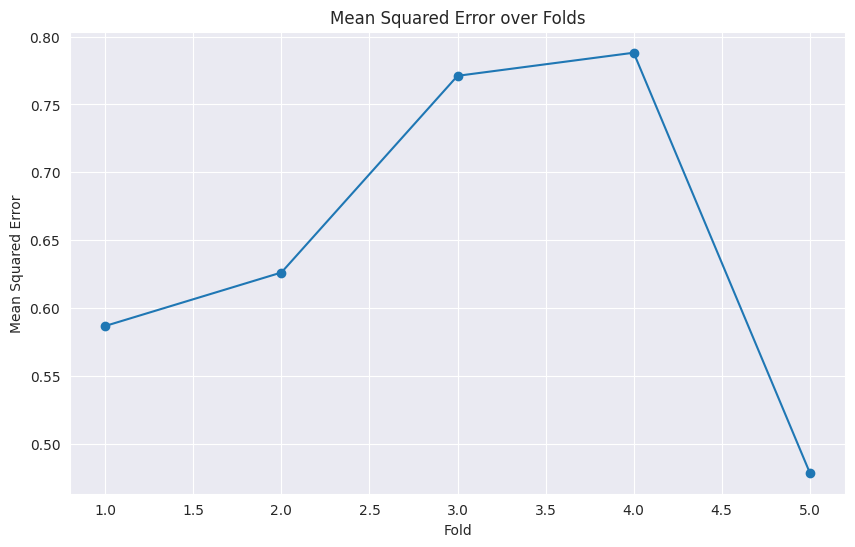


Classification Report for the ensemble:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      6561
           1       0.94      0.88      0.91      7478
           2       0.89      0.92      0.90      6651
           3       0.91      0.90      0.91      6745
           4       0.87      0.90      0.89      6475
           5       0.88      0.91      0.89      6015
           6       0.90      0.96      0.93      6507
           7       0.86      0.93      0.89      6935
           8       0.90      0.84      0.87      6483
           9       0.96      0.89      0.92      6650

    accuracy                           0.91     66500
   macro avg       0.91      0.91      0.91     66500
weighted avg       0.91      0.91      0.91     66500



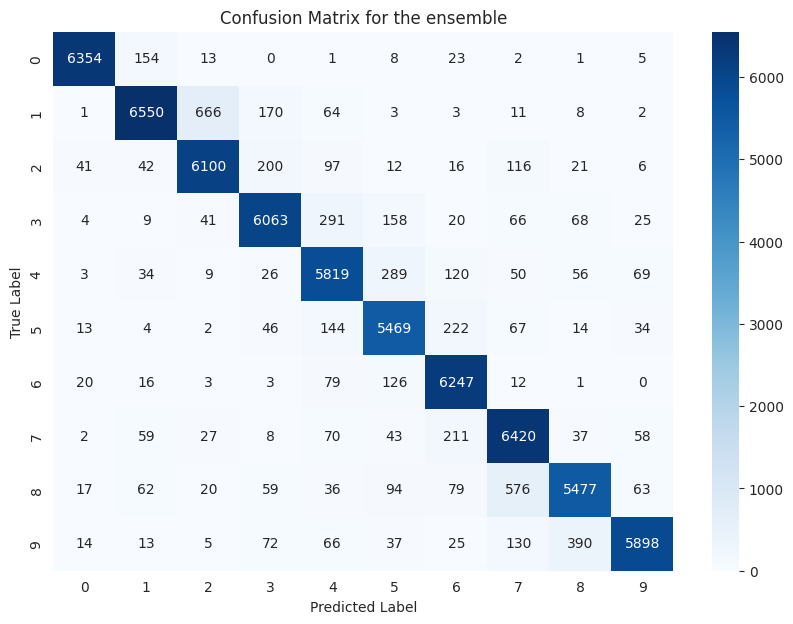

In [7]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor

output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

mnist_embedding = mnist_features_normalized_left_out
mnist_labels_int = mnist_labels_left_out.astype(int)

# Dataset for final evaluation
mnist_features_remaining = mnist_features_normalized[leave_out_size:]
mnist_labels_remaining = mnist_labels[leave_out_size:].astype(int)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the mean squared error and other metrics for each fold
mse_scores = []
baseline_mse_scores = []
loss_history = []
accuracy_scores = []

# To store the models
models = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_embedding)
current_fold = 1

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

for train_index, test_index in kf.split(mnist_embedding):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_embedding[train_index], mnist_embedding[test_index]
    y_train, y_test = mnist_labels_int[train_index], mnist_labels_int[test_index]
    
    # Reshape y_train to be a 1D array
    y_train = y_train.ravel()
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    models.append(best_rf)
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Round predictions to nearest integer
    y_pred_rounded = np.round(y_pred)
    
    # Calculate the mean squared error for this fold
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    loss_history.append(mse)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_rounded)
    accuracy_scores.append(accuracy)
    
    # Baseline model: predict the mean of y_train
    baseline_pred = np.mean(y_train)
    baseline_mse = mean_squared_error(y_test, np.full_like(y_test, baseline_pred))
    baseline_mse_scores.append(baseline_mse)
    
    print(f"Fold {current_fold}/{total_folds} MSE: {mse}, Baseline MSE: {baseline_mse}, Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average mean squared error and accuracy across all folds
avg_mse = np.mean(mse_scores)
avg_baseline_mse = np.mean(baseline_mse_scores)
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average Baseline Mean Squared Error: {avg_baseline_mse}')
print(f'Average Accuracy: {avg_accuracy}')

# Ensemble predictions on the remaining dataset
ensemble_predictions = np.zeros(mnist_labels_remaining.shape[0])

for model in models:
    ensemble_predictions += model.predict(mnist_features_remaining)

# Average the predictions
ensemble_predictions /= len(models)
ensemble_predictions_rounded = np.round(ensemble_predictions)

# Evaluate ensemble performance
ensemble_mse = mean_squared_error(mnist_labels_remaining, ensemble_predictions)
ensemble_accuracy = accuracy_score(mnist_labels_remaining, ensemble_predictions_rounded)
print(f'Ensemble Mean Squared Error: {ensemble_mse}')
print(f'Ensemble Accuracy: {ensemble_accuracy}')

# Plot the evolution of the loss (mean squared error) over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('Mean Squared Error over Folds')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the ensemble
print("\nClassification Report for the ensemble:")
print(classification_report(mnist_labels_remaining, ensemble_predictions_rounded))

conf_matrix = confusion_matrix(mnist_labels_remaining, ensemble_predictions_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 1/5 MSE: 0.5888881245104405, Baseline MSE: 8.602642857142857, Accuracy: 0.9522142857142857
Model checkpoint saved for fold 1 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 2/5 MSE: 0.5676944542358917, Baseline MSE: 8.579142857142857, Accuracy: 0.9528571428571428
Model checkpoint saved for fold 2 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_2.pkl
Starting fold 3/5
Training completed for fold 3/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 3/5 MSE: 0.5237669590118222, Baseline MSE: 8.5105, Accuracy: 0.9513571428571429
Model checkpoint saved for fold 3 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_

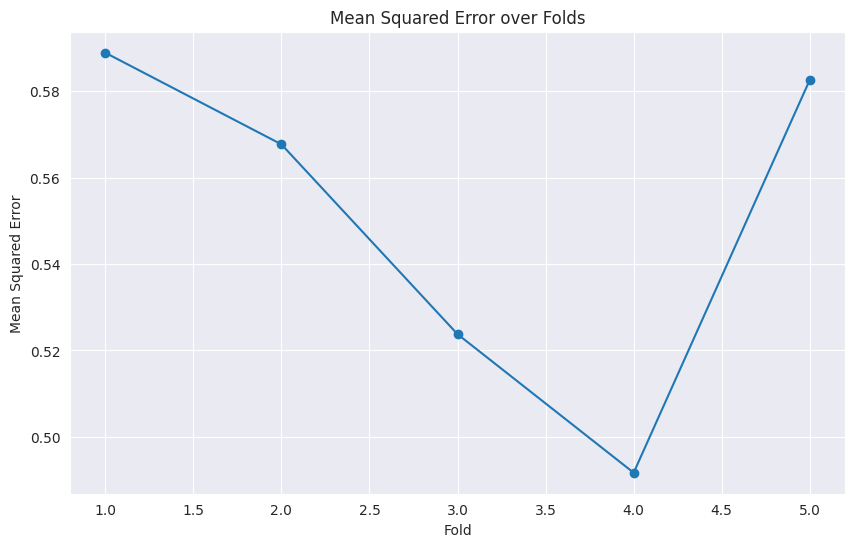


Classification Report for the last fold:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1375
           1       0.95      0.95      0.95      1613
           2       0.95      0.95      0.95      1414
           3       0.96      0.94      0.95      1414
           4       0.94      0.95      0.95      1364
           5       0.95      0.95      0.95      1265
           6       0.96      0.99      0.97      1360
           7       0.94      0.97      0.96      1429
           8       0.94      0.93      0.93      1375
           9       0.96      0.92      0.94      1391

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000



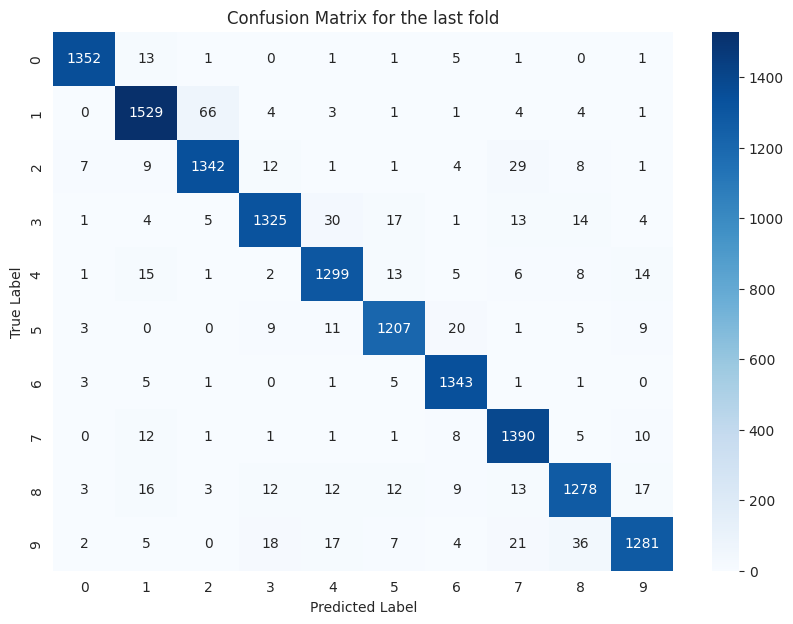

In [8]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor

output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

mnist_embedding = mnist_features_normalized_left_out
mnist_labels_int = mnist_labels_left_out.astype(int)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the mean squared error and other metrics for each fold
mse_scores = []
baseline_mse_scores = []
loss_history = []
accuracy_scores = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_embedding)
current_fold = 1

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

for train_index, test_index in kf.split(mnist_embedding):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_embedding[train_index], mnist_embedding[test_index]
    y_train, y_test = mnist_labels_int[train_index], mnist_labels_int[test_index]
    
    # Reshape y_train to be a 1D array
    y_train = y_train.ravel()
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Round predictions to nearest integer
    y_pred_rounded = np.round(y_pred)
    
    # Calculate the mean squared error for this fold
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    loss_history.append(mse)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_rounded)
    accuracy_scores.append(accuracy)
    
    # Baseline model: predict the mean of y_train
    baseline_pred = np.mean(y_train)
    baseline_mse = mean_squared_error(y_test, np.full_like(y_test, baseline_pred))
    baseline_mse_scores.append(baseline_mse)
    
    print(f"Fold {current_fold}/{total_folds} MSE: {mse}, Baseline MSE: {baseline_mse}, Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average mean squared error and accuracy across all folds
avg_mse = np.mean(mse_scores)
avg_baseline_mse = np.mean(baseline_mse_scores)
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average Baseline Mean Squared Error: {avg_baseline_mse}')
print(f'Average Accuracy: {avg_accuracy}')

# Plot the evolution of the loss (mean squared error) over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('Mean Squared Error over Folds')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the last fold
print("\nClassification Report for the last fold:")
print(classification_report(y_test, y_pred_rounded))

conf_matrix = confusion_matrix(y_test, y_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the last fold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


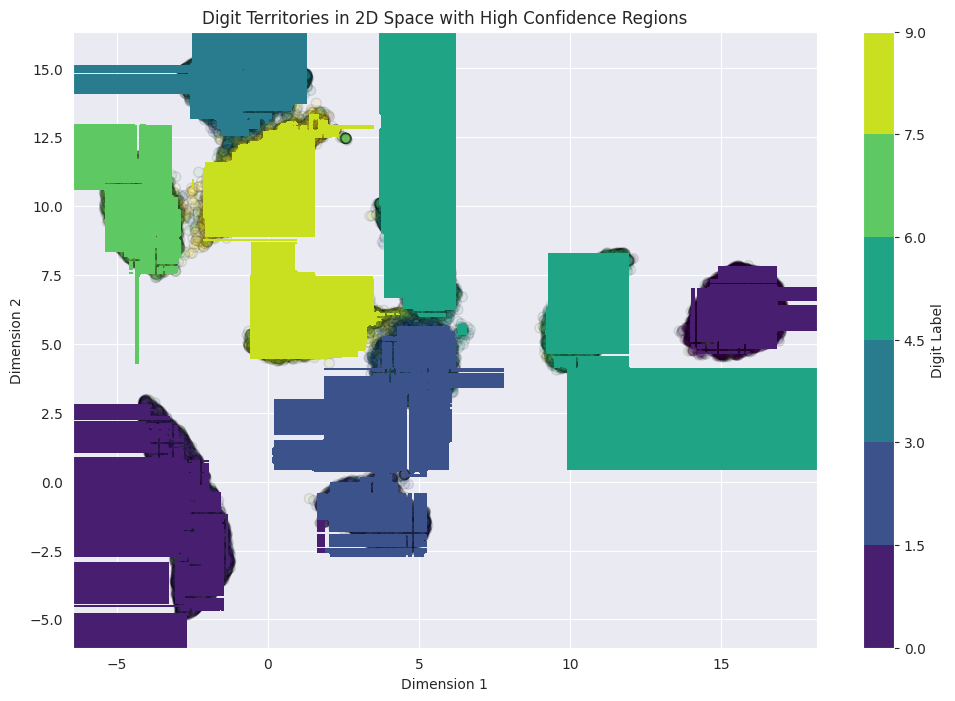

In [26]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Function to load the model checkpoints
def load_model_checkpoint(folder, fold_number):
    checkpoint_path = os.path.join(folder, f'rf_model_fold_{fold_number}.pkl')
    with open(checkpoint_path, 'rb') as f:
        model = pickle.load(f)
    return model

# Define the output folder where the models are saved
output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

# Number of folds
k = 5

# Load the model from the last fold (or you can choose any specific fold)
last_fold_number = k
rf_model = load_model_checkpoint(output_folder, last_fold_number)

# Generate a mesh grid of points in the 2D space
x_min, x_max = mnist_embedding[:, 0].min() - 1, mnist_embedding[:, 0].max() + 1
y_min, y_max = mnist_embedding[:, 1].min() - 1, mnist_embedding[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Flatten the grid so it can be used as input to the model
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the digit labels for each point in the mesh grid and calculate standard deviation of predictions
tree_predictions = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
mean_predictions = np.mean(tree_predictions, axis=0)
std_predictions = np.std(tree_predictions, axis=0)

# Round the predictions to the nearest integer
predicted_labels_rounded = np.round(mean_predictions).astype(int)

# Reshape the predicted labels and standard deviations to match the shape of the mesh grid
predicted_labels_reshaped = predicted_labels_rounded.reshape(xx.shape)
std_predictions_reshaped = std_predictions.reshape(xx.shape)

# Define a threshold for high confidence (e.g., std deviation <= 0.5 indicates high confidence)
confidence_threshold = 0.5
high_confidence_mask = std_predictions_reshaped <= confidence_threshold

# Apply the high confidence mask to the predicted labels
high_confidence_predictions = np.where(high_confidence_mask, predicted_labels_reshaped, np.nan)

# Plot the digit territories with high confidence regions
plt.figure(figsize=(12, 8))
plt.scatter(mnist_embedding[:, 0], mnist_embedding[:, 1], c=mnist_labels_int, edgecolor='k', s=50, cmap='viridis', alpha=0.1)
plt.contourf(xx, yy, high_confidence_predictions, cmap='viridis', alpha=1)
plt.colorbar(label='Digit Label')
plt.title('Digit Territories in 2D Space with High Confidence Regions')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


In [1]:
# list niftis in /gamma/Dropbox\ \(GIN\)/EMUSE/DSD_repro/disco_1333
from pathlib import Path

disco_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_1333'

# list nifti files in lesions_folder
disco_list = [p for p in Path(disco_folder).iterdir() if p.is_file()]

# disco_input_matrix with nifti_dataset_to_matrix
from tools.inputs_utils import nifti_dataset_to_matrix

disco_input_matrix = nifti_dataset_to_matrix(disco_list)

# train a umap on disco_input_matrix and save in /gamma/Dropbox\ \(GIN\)/EMUSE/DSD_repro/emuse_results with train_and_save_umap_and_embeddings
from tools.UMAP_utils import train_and_save_umap_and_embeddings

output_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results'
# use seed 42
trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(disco_input_matrix, output_folder, 'disco', random_state=42)


1333it [00:36, 36.38it/s]
/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


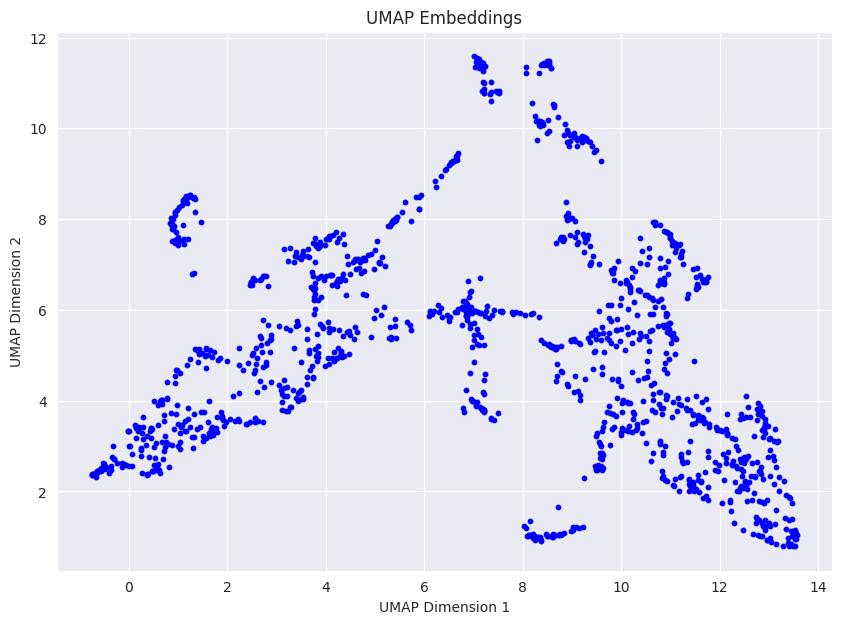

In [4]:
# plot the embeddings
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='b', s=10)
plt.title('UMAP Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()


In [1]:
# create a disco_dls and create the different spaces. 
from tools.emuse_utils import DiscreteLatentSpace

umap_path = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/disco_umap_model_joblib1.3.1.joblib'

disco_dls = DiscreteLatentSpace(umap_path, margin=5)

# rescale the embedding
disco_dls.rescale_embedding(disco_dls.raw_embeddings)

# create the discrete space
disco_dls.create_discrete_space(disco_dls.rescaled_embeddings, 10)


Loading the trained UMAP model to get the embeddings
There is an overlap of 9.60% points in the discrete space
The number of cells in the discrete space is 147854
The shape of the discrete space is (413, 358)
Maximum in each dimension: 13.565800666809082


In [31]:
from bcblib.tools.general_utils import parse_file_list_argument
from tools.inputs_utils import load_and_preprocess_mnist_dataset, nifti_dataset_to_matrix
# load the scores
import pandas as pd
import numpy as np
from pathlib import Path

# create a heatmap with the left out features and labels
# training set /gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_119 and scores: /gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_complete.xlsx
# test set /gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_24 and scores /gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_20.xlsx

# load the scores
training_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_complete.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)

# create_heatmap_data
from tools.inputs_utils import create_heatmap_data

training_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_119/'
training_files_list = parse_file_list_argument(training_files_folder)
# the column names are the filenames without extension. Transpose the spreadsheet and replace the indices (filenames) with the file paths (matched with the training_files_list)
training_spreadsheet = training_spreadsheet.T
filename_list = training_spreadsheet.index
# find each filename in the training_files_list
for filename in filename_list:
    for training_file in training_files_list:
        if filename in training_file:
            training_spreadsheet.rename(index={filename: training_file}, inplace=True)
            break
            
# create an input_matrix with the indices (file paths now) which are in the right order
training_input_matrix = nifti_dataset_to_matrix(training_spreadsheet.index)
# 
# training_embeddings = disco_dls.trained_umap.transform(training_input_matrix)
# 
# np.save('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy', training_embeddings)

Found 119 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_119


119it [00:02, 42.99it/s]


Shape of matched embeddings: (119, 2)
Shape of matched embeddings after removing NaNs and Infs: (75, 2)
Setting discrete embedding with shape None
Created heatmap pos_acc_disengage
Setting discrete embedding with shape (413, 358)
Created heatmap rescaled and discrete space pos_acc_disengage
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (75, 413, 358)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (75, 413, 358)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


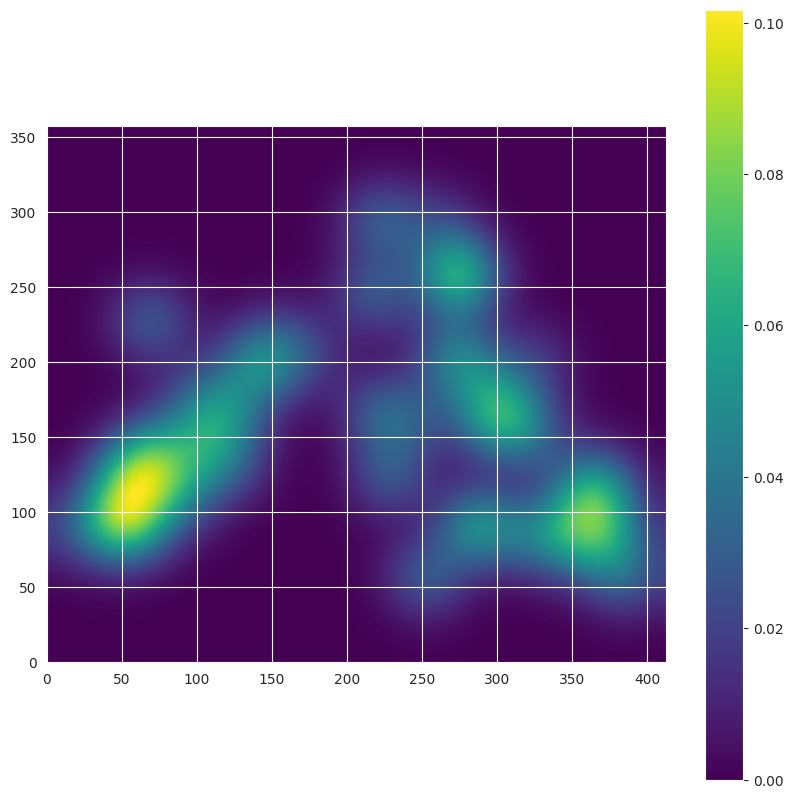

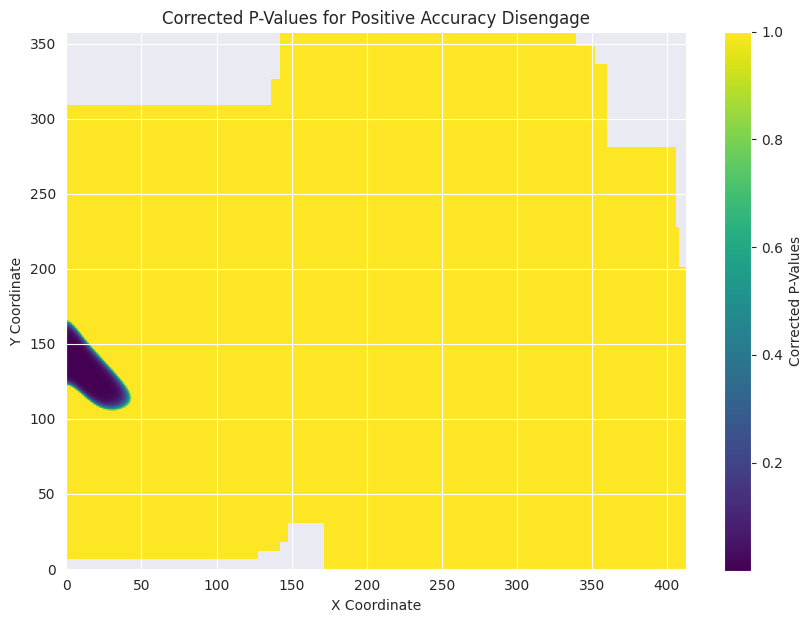

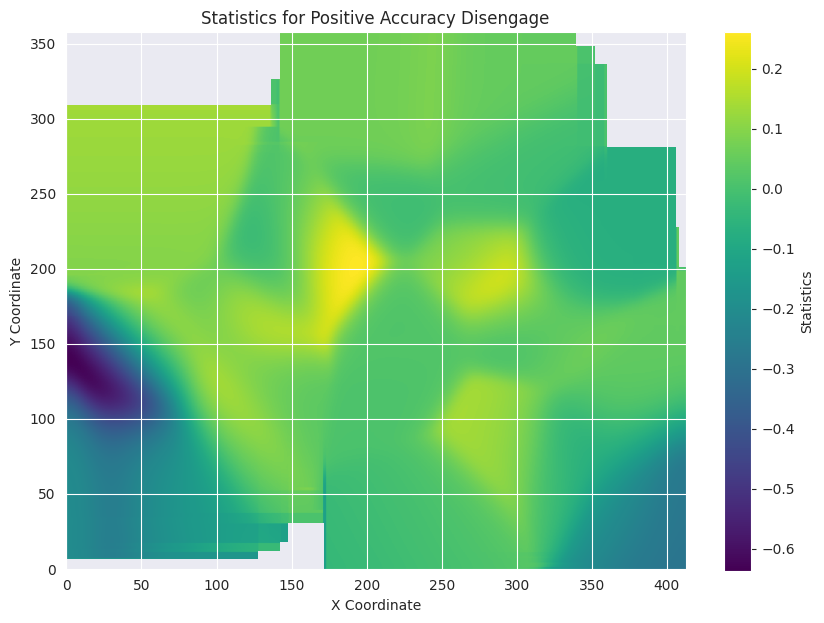

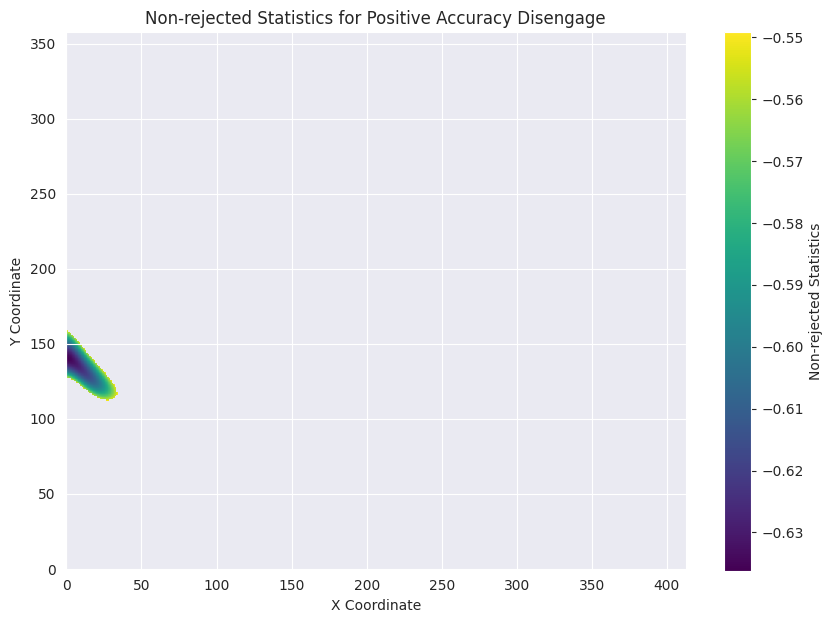

In [56]:
from tools.emuse_utils import compute_stats_on_corrected_clusters, compute_stats_on_smoothed_nplusone_dim_discrete_space

score_tag = 'pos_acc_disengage'
scores = training_spreadsheet[score_tag].to_numpy()
training_embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy')
# training_embeddings is a 2D array, the coordinates should be a tuple (x, y) (one tuple per row)
training_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
training_df['scores'] = scores
# create the heatmap data
# delete the heatmap
if 'pos_acc_disengage' in disco_dls.heatmaps:
    disco_dls.delete_heatmap('pos_acc_disengage')
if 'pos_acc_disengage' not in disco_dls.heatmaps:
    disco_dls.create_heatmap_spaces(training_df, 'pos_acc_disengage', smoothing_fwhm=None, smoothing_sigma=20)

# plot the heatmap
disco_dls.plot_heatmap('pos_acc_disengage')

# use compute_stats_on_corrected_clusters on the heatmap and plot it
statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(disco_dls.heatmaps['pos_acc_disengage'], disco_dls.heatmaps['pos_acc_disengage'].scores, correction_method='holm')

# plot the heatmap with the corrected pvalues
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(corrected_pvalues.T, cmap='viridis', origin='lower')
plt.colorbar(label='Corrected P-Values')
plt.title('Corrected P-Values for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# Plot the statistics
plt.figure(figsize=(10, 7))
plt.imshow(statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Statistics')
plt.title('Statistics for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# Create a mask for the rejected hypotheses
reject_mask = np.ma.masked_where(corrected_pvalues > 0.05, statistics)

# Plot the statistics that are not rejected
plt.figure(figsize=(10, 7))
plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
plt.colorbar(label='Non-rejected Statistics')
plt.title('Non-rejected Statistics for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


In [24]:
# Load the scores
test_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_20.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)

# Parse the file list
test_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_24/'
test_files_list = parse_file_list_argument(test_files_folder)

# Match the filenames with the file paths
test_spreadsheet = test_spreadsheet.T
filename_list = test_spreadsheet.index

# List to store the filenames that were matched
matched_filenames = []

for filename in filename_list:
    # find each filename in the test_files_list and replace the filename with the full path
    for file_path in test_files_list:
        if Path(file_path).name.lower() == filename.lower():  # convert both to lower case for comparison
            test_spreadsheet = test_spreadsheet.rename(index={filename: file_path})
            matched_filenames.append(filename)
            break

# Find the filenames that could not be replaced
not_matched_filenames = set(filename_list) - set(matched_filenames)

print(f"The following filenames could not be replaced because they were not found: {not_matched_filenames}")
# Create an input matrix with the matched file paths
test_input_matrix = nifti_dataset_to_matrix(test_spreadsheet.index)

# Get the embeddings using the trained UMAP
test_embeddings = disco_dls.trained_umap.transform(test_input_matrix)

# Save the embeddings
np.save('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/test_embeddings.npy', test_embeddings)

# Create a DataFrame with the embeddings and scores
score_tag = 'pos_acc_disengage'
scores = test_spreadsheet[score_tag].to_numpy()
test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = scores

Found 24 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_24
The following filenames could not be replaced because they were not found: set()


20it [00:00, 43.20it/s]


Validation MSE: 0.0014997073763348334, Validation MAE: 0.02898332333333333
Normalized Validation MSE: 1.34%, Normalized Validation MAE: 8.65%
Validation MSE: 0.0032143826666666668, Validation MAE: 0.04255333333333334
Normalized Validation MSE: 2.86%, Normalized Validation MAE: 12.70%
Validation MSE: 0.0006695304227095002, Validation MAE: 0.02215672333333334
Normalized Validation MSE: 0.60%, Normalized Validation MAE: 6.61%
Validation MSE: 0.003817556034999994, Validation MAE: 0.04359366666666664
Normalized Validation MSE: 3.40%, Normalized Validation MAE: 13.01%
Validation MSE: 0.004757730845667832, Validation MAE: 0.03908333666666666
Normalized Validation MSE: 4.24%, Normalized Validation MAE: 11.67%
Test MSE: 0.0018974124903621574
Test MAE: 0.03373042210526316
Normalized Test MSE: 1.69%, Normalized Test MAE: 10.07%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/model_

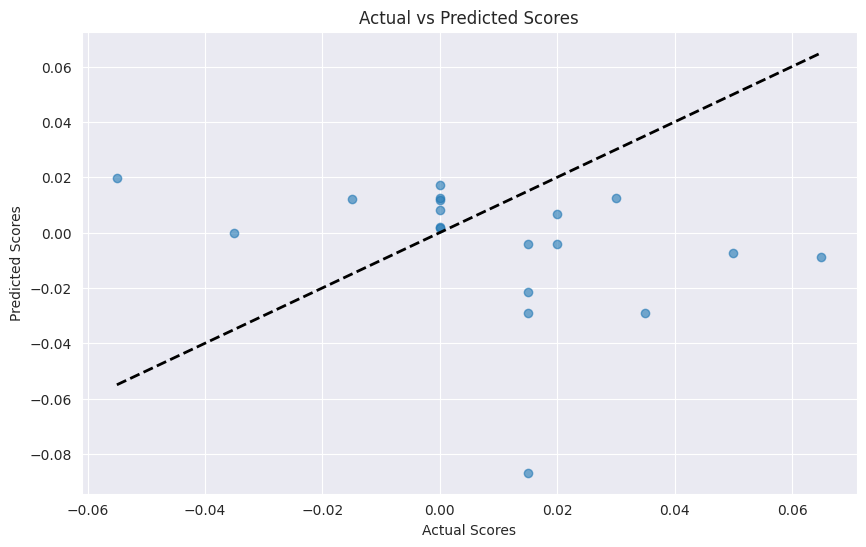

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import os

# Define the directory to save the models
model_save_dir = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/'
os.makedirs(model_save_dir, exist_ok=True)

# Load your training and test dataframes
# Assuming training_df and test_df are already loaded

# Drop rows with NaN values in train_scores
training_df = training_df.dropna(subset=['scores'])

# Drop rows with NaN values in test_scores
test_df = test_df.dropna(subset=['scores'])

# Extract coordinates and scores from training data
train_coords = np.array([list(coord) for coord in training_df['embeddings']])
train_scores = training_df['scores'].values

# Extract coordinates and scores from test data
test_coords = np.array([list(coord) for coord in test_df['embeddings']])
test_scores = test_df['scores'].values

# Determine the range of possible values
min_score = min(np.min(train_scores), np.min(test_scores))
max_score = max(np.max(train_scores), np.max(test_scores))
range_of_values = max_score - min_score

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the trained models
models = []

# List to store MAE for validation sets
mae_scores = []

# Train multiple models using k-fold cross-validation
for train_index, val_index in kf.split(train_coords):
    X_train, X_val = train_coords[train_index], train_coords[val_index]
    y_train, y_val = train_scores[train_index], train_scores[val_index]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Store the trained model
    models.append(model)
    
    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mae_scores.append(mae_val)
    
    # Normalize errors
    normalized_mae_val = (mae_val / range_of_values) * 100
    normalized_mse_val = (mse_val / (range_of_values ** 2)) * 100
    print(f'Validation MSE: {mse_val}, Validation MAE: {mae_val}')
    print(f'Normalized Validation MSE: {normalized_mse_val:.2f}%, Normalized Validation MAE: {normalized_mae_val:.2f}%')

# Make predictions on the test data using the ensemble of models
test_predictions = np.zeros(test_coords.shape[0])
for model in models:
    test_predictions += model.predict(test_coords)
test_predictions /= len(models)

# Calculate the Mean Squared Error and Mean Absolute Error on the test data
mse_test = mean_squared_error(test_scores, test_predictions)
mae_test = mean_absolute_error(test_scores, test_predictions)

# Normalize errors
normalized_mae_test = (mae_test / range_of_values) * 100
normalized_mse_test = (mse_test / (range_of_values ** 2)) * 100

print(f'Test MSE: {mse_test}')
print(f'Test MAE: {mae_test}')
print(f'Normalized Test MSE: {normalized_mse_test:.2f}%, Normalized Test MAE: {normalized_mae_test:.2f}%')

# Save the models
for i, model in enumerate(models):
    model_path = os.path.join(model_save_dir, f'model_fold_{i}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Model {i} saved to {model_path}')

# Visualize the predictions vs. actual scores (optional)
plt.figure(figsize=(10, 6))
plt.scatter(test_scores, test_predictions, alpha=0.6)
plt.plot([test_scores.min(), test_scores.max()], [test_scores.min(), test_scores.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.show()


Validation MSE: 0.0024159429863408336, Validation MAE: 0.03674997000000001
Normalized Validation MSE: 2.15%, Normalized Validation MAE: 10.97%
Validation MSE: 0.003040875367334333, Validation MAE: 0.04116000666666666
Normalized Validation MSE: 2.71%, Normalized Validation MAE: 12.29%
Validation MSE: 0.0003659695004111667, Validation MAE: 0.01587658333333333
Normalized Validation MSE: 0.33%, Normalized Validation MAE: 4.74%
Validation MSE: 0.0014369449350000005, Validation MAE: 0.03028366666666667
Normalized Validation MSE: 1.28%, Normalized Validation MAE: 9.04%
Validation MSE: 0.0042261984426928325, Validation MAE: 0.03699331666666666
Normalized Validation MSE: 3.77%, Normalized Validation MAE: 11.04%
Test MSE: 0.0017876661845131995
Test MAE: 0.03177943052631579
Normalized Test MSE: 1.59%, Normalized Test MAE: 9.49%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_new/model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_ne

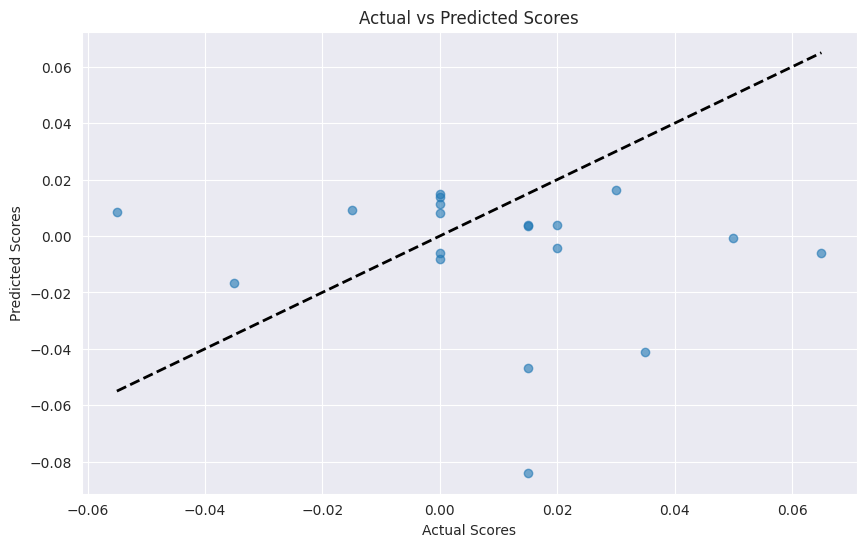

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import os

# Define the directory to save the models
new_model_save_dir = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_new/'
os.makedirs(new_model_save_dir, exist_ok=True)

# Load your training and test dataframes
# Assuming training_df and test_df are already loaded
# Assuming train_input_matrix and test_input_matrix are already loaded

# Drop rows with NaN values in scores and get the indices
train_valid_indices = training_df.dropna(subset=['scores']).index
test_valid_indices = test_df.dropna(subset=['scores']).index

# Filter the train_input_matrix and test_input_matrix based on the non-NaN scores
train_input_filtered = training_input_matrix[train_valid_indices]
train_scores_filtered = training_df.loc[train_valid_indices, 'scores'].values

test_input_filtered = test_input_matrix[test_valid_indices]
test_scores_filtered = test_df.loc[test_valid_indices, 'scores'].values

# Determine the range of possible values
min_score = min(np.min(train_scores_filtered), np.min(test_scores_filtered))
max_score = max(np.max(train_scores_filtered), np.max(test_scores_filtered))
range_of_values = max_score - min_score

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the trained models
new_models = []

# List to store MAE for validation sets
new_mae_scores = []

# Train multiple models using k-fold cross-validation
for train_index, val_index in kf.split(train_input_filtered):
    X_train, X_val = train_input_filtered[train_index], train_input_filtered[val_index]
    y_train, y_val = train_scores_filtered[train_index], train_scores_filtered[val_index]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Store the trained model
    new_models.append(model)
    
    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    new_mae_scores.append(mae_val)
    
    # Normalize errors
    normalized_mae_val = (mae_val / range_of_values) * 100
    normalized_mse_val = (mse_val / (range_of_values ** 2)) * 100
    print(f'Validation MSE: {mse_val}, Validation MAE: {mae_val}')
    print(f'Normalized Validation MSE: {normalized_mse_val:.2f}%, Normalized Validation MAE: {normalized_mae_val:.2f}%')

# Make predictions on the test data using the ensemble of models
test_predictions = np.zeros(test_input_filtered.shape[0])
for model in new_models:
    test_predictions += model.predict(test_input_filtered)
test_predictions /= len(new_models)

# Calculate the Mean Squared Error and Mean Absolute Error on the test data
mse_test = mean_squared_error(test_scores_filtered, test_predictions)
mae_test = mean_absolute_error(test_scores_filtered, test_predictions)

# Normalize errors
normalized_mae_test = (mae_test / range_of_values) * 100
normalized_mse_test = (mse_test / (range_of_values ** 2)) * 100

print(f'Test MSE: {mse_test}')
print(f'Test MAE: {mae_test}')
print(f'Normalized Test MSE: {normalized_mse_test:.2f}%, Normalized Test MAE: {normalized_mae_test:.2f}%')

# Save the models
for i, model in enumerate(new_models):
    model_path = os.path.join(new_model_save_dir, f'model_fold_{i}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Model {i} saved to {model_path}')

# Visualize the predictions vs. actual scores (optional)
plt.figure(figsize=(10, 6))
plt.scatter(test_scores_filtered, test_predictions, alpha=0.6)
plt.plot([test_scores_filtered.min(), test_scores_filtered.max()], [test_scores_filtered.min(), test_scores_filtered.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.show()
